# Análise e Previsão da Potência Gerada por Turbina Eólica: Um Estudo Comparativo de Modelos Preditivos

## Introdução

Este notebook apresenta um experimento acadêmico focado na previsão da potência gerada por turbinas eólicas. Serão exploradas diferentes metodologias de modelagem, desde baselines simples até modelos de aprendizado de máquina avançados e redes neurais recorrentes, visando identificar o modelo com melhor desempenho para horizontes de previsão de até 6 horas.

In [1]:
!pip install lightgbm optuna scikit-posthocs -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.7 MB/s eta 0:00:00


## 1. Configuração Inicial

Esta seção prepara o ambiente, instalando as bibliotecas necessárias e configurando parâmetros globais para garantir a reprodutibilidade do experimento.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.multioutput import MultiOutputRegressor

from lightgbm import LGBMRegressor

from scipy.stats import friedmanchisquare

import scikit_posthocs as sp

In [ ]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## 2. Carregamento e Exploração Inicial dos Dados

Nesta etapa, os dados da potência gerada e variáveis meteorológicas são carregados e uma análise exploratória inicial é realizada para entender sua estrutura, identificar padrões e detectar a presença de valores ausentes (gaps).

In [3]:
TARGET = "potencia_gerada"

FORECAST_STEPS = [
    1,   # 1h
    2,   # 2h
    3,  # 3h
    4,  # 4h
    5,  # 5h
    6   # 6h
]

LAG_OPTIONS = [
    2,   # 2h
    4,  # 4h
    6   # 6h
]

N_SPLITS = 5

In [ ]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path(
    "../data_preprocessing/outputs/reindexed/dfrs_reindexed.xlsx"
)

df = pd.read_excel(DATA_PATH)

In [5]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"]
)

df = df.sort_values(
    "timestamp"
)

df = df.set_index(
    "timestamp"
)

df.head()

,data,hora_local,potencia_gerada,vento_velocidade,temp_inst,humidade_inst,ponto_orvalho_celsius,pressao_inst,vento_direcao,precipitacao
timestamp,,,,,,,,,,
2020-02-15 00:00:00,2020-02-15 00:00:00,0,0.00,0.1,21.3,96,20.7,1008.7,355,0.0
2020-02-15 01:00:00,2020-02-15 01:00:00,1,0.00,2.1,20.6,97,20.1,1008.5,284,0.0
2020-02-15 02:00:00,2020-02-15 02:00:00,2,0.00,1.9,19.9,97,19.5,1008.4,253,0.0
2020-02-15 03:00:00,2020-02-15 03:00:00,3,0.00,1.7,20.5,98,20.1,1008.4,232,0.0
2020-02-15 04:00:00,2020-02-15 04:00:00,4,31.66,4.1,21.2,98,20.8,1008.3,192,0.0


In [6]:
TARGET = "potencia_gerada"

df_gap = df.copy()

df_gap["is_gap"] = (
    df_gap[TARGET].isna()
).astype(int)

print(
    f"Total de registros: {len(df_gap):,}"
)

print(
    f"Registros com gap: {df_gap['is_gap'].sum():,}"
)

print(
    f"% faltante: {100*df_gap['is_gap'].mean():.2f}%"
)

Total de registros: 8,184
Registros com gap: 0
% faltante: 0.00%


In [7]:
df_gap["gap_group"] = (
    df_gap["is_gap"]
      .ne(df_gap["is_gap"].shift())
      .cumsum()
)

gap_sizes = (

    df_gap[df_gap["is_gap"] == 1]

    .groupby("gap_group")

    .size()

    .reset_index(name="gap_size")

)

gap_sizes.head()

,gap_group,gap_size


In [ ]:
gap_sizes["gap_minutes"] = (
    gap_sizes["gap_size"] * 60
)

gap_sizes["gap_hours"] = (
    gap_sizes["gap_minutes"] / 60
)

gap_sizes.describe()

,gap_group,gap_size,gap_minutes,gap_hours
count,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN


In [10]:
gap_sizes.sort_values(
    "gap_hours",
    ascending=False
).head(20)

,gap_group,gap_size,gap_minutes,gap_hours


## 2. Carregamento e Exploração Inicial dos Dados

Nesta etapa, os dados da potência gerada e variáveis meteorológicas são carregados e uma análise exploratória inicial é realizada para entender sua estrutura, identificar padrões e detectar a presença de valores ausentes (gaps).

### 2.3 Tabela Resumo dos Gaps

Uma tabela resumo é criada para categorizar os gaps por tamanho e apresentar estatísticas como quantidade, média e máximo de registros por categoria.

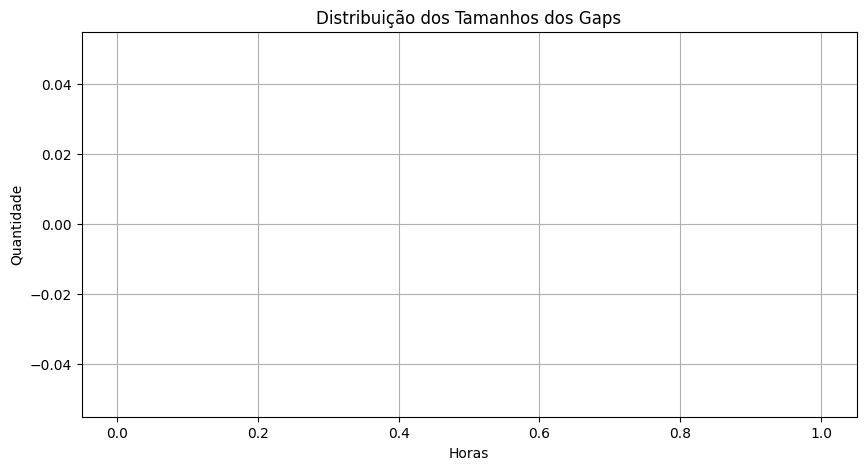

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

gap_sizes["gap_hours"].hist(
    bins=50
)

plt.xlabel("Horas")

plt.ylabel("Quantidade")

plt.title(
    "Distribuição dos Tamanhos dos Gaps"
)

plt.show()

### 2.3 Tabela Resumo dos Gaps

Uma tabela resumo é criada para categorizar os gaps por tamanho e apresentar estatísticas como quantidade, média e máximo de registros por categoria.

In [12]:
def classify_gap(size):

    if size <= 1:
        return "Até 1h"

    elif size <= 6:
        return "1h-6h"

    elif size <= 24:
        return "6h-24h"

    else:
        return ">24h"

In [13]:
gap_sizes["categoria"] = (
    gap_sizes["gap_size"]
      .apply(classify_gap)
)

gap_sizes["categoria"].value_counts()

,count
categoria,


In [14]:
gap_table = (

    gap_sizes

    .groupby("categoria")

    .agg(
        quantidade=("gap_size","count"),
        media_registros=("gap_size","mean"),
        max_registros=("gap_size","max")
    )

)

gap_table

,quantidade,media_registros,max_registros
categoria,,,


In [15]:
gap_table.reset_index()

,categoria,quantidade,media_registros,max_registros


### 2.4 Ocorrência Temporal dos Gaps

Este gráfico visualiza a distribuição temporal dos gaps, indicando os períodos em que as interrupções nos dados são mais frequentes.

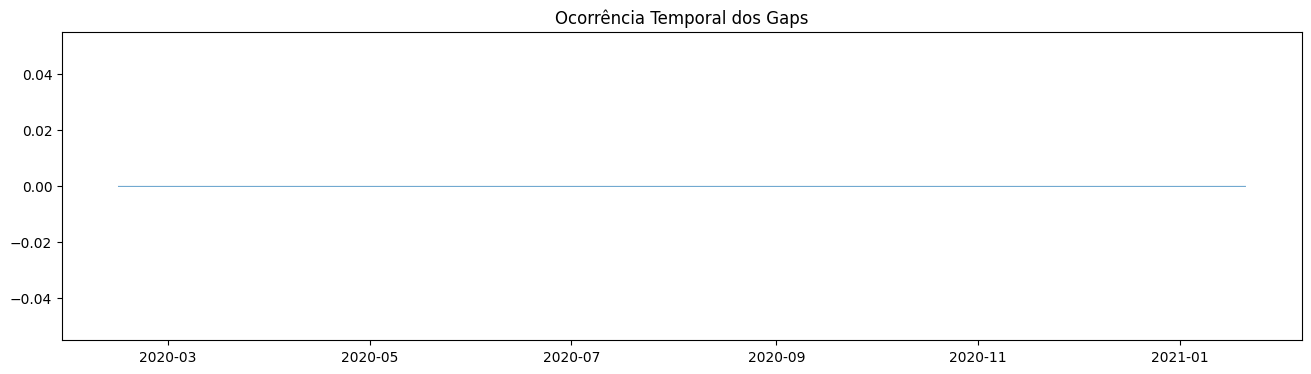

In [16]:
plt.figure(figsize=(16,4))

plt.plot(
    df_gap.index,
    df_gap["is_gap"],
    linewidth=0.5
)

plt.title(
    "Ocorrência Temporal dos Gaps"
)

plt.show()

In [17]:
missing_table = (

    df.isna()

    .mean()

    .mul(100)

    .sort_values(
        ascending=False
    )

    .to_frame(
        "percentual_missing"
    )

)

missing_table

,percentual_missing
data,0.0
hora_local,0.0
potencia_gerada,0.0
vento_velocidade,0.0
temp_inst,0.0
humidade_inst,0.0
ponto_orvalho_celsius,0.0
pressao_inst,0.0
vento_direcao,0.0
precipitacao,0.0


### 2.5 Informações Detalhadas dos Gaps

Nesta seção, são extraídas informações mais detalhadas sobre os gaps, incluindo suas datas de início e fim, duração em registros e dias.

In [21]:
gap_info = []

for gid in gap_sizes["gap_group"]:

    tmp = df_gap[df_gap["gap_group"] == gid]

    gap_info.append({
        "gap_group": gid,
        "inicio": tmp.index.min(),
        "fim": tmp.index.max(),
        "registros": len(tmp),
        "dias": len(tmp)*1/1/24
    })

gap_info = pd.DataFrame(gap_info)

# Check if the DataFrame is empty before attempting to sort and display.
# If it's empty, attempting to sort by a non-existent column 'dias' will cause a KeyError.
# Simply checking if it's empty will prevent this, and an empty DataFrame will be displayed.
if not gap_info.empty:
    gap_info.sort_values(
        "dias",
        ascending=False
    ).head(10)
else:
    print("A DataFrame com informações de lacunas (gap_info) está vazia porque não foram encontrados gaps nos dados.")

A DataFrame com informações de lacunas (gap_info) está vazia porque não foram encontrados gaps nos dados.


In [23]:
plt.figure(figsize=(14,5))

if not gap_info.empty:
    plt.scatter(
        gap_info["inicio"],
        gap_info["dias"]
    )

    plt.ylabel("Dias")

    plt.title(
        "Tamanho dos Gaps ao Longo do Tempo"
    )

    plt.show()
else:
    print("A DataFrame com informações de lacunas (gap_info) está vazia, portanto não há gaps para plotar.")

A DataFrame com informações de lacunas (gap_info) está vazia, portanto não há gaps para plotar.


<Figure size 1400x500 with 0 Axes>

### 2.6 Visualização Temporal dos Gaps

Um gráfico de dispersão é utilizado para visualizar a duração dos gaps ao longo do tempo, auxiliando na identificação de padrões ou tendências.

In [24]:
TARGET_BENCH = "potencia_gerada"

In [25]:
series_clean = (

    df[TARGET_BENCH]

    .dropna()

)

In [26]:
def create_artificial_gap(
    series,
    gap_size,
    seed=42
):

    rng = np.random.default_rng(seed)

    start = rng.integers(
        100,
        len(series)-gap_size-100
    )

    original = series.copy()

    masked = series.copy()

    mask = np.zeros(
        len(series),
        dtype=bool
    )

    mask[start:start+gap_size] = True

    masked.iloc[
        start:start+gap_size
    ] = np.nan

    return original, masked, mask

In [27]:
def impute_time(masked):

    return masked.interpolate(
        method="time"
    )

In [28]:
def impute_ffill(masked):

    return masked.ffill()

In [29]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

def evaluate_imputation(
    original,
    imputed,
    mask
):

    y_true = original[mask]

    y_pred = imputed[mask]

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    return mae, rmse

In [30]:
results = []

for gap_size in [
    1,
    2,
    4,
    8,
    24,
    96
]:

    original, masked, mask = create_artificial_gap(
        series_clean,
        gap_size
    )

    gap_mask = masked.isna()

    # interpolação

    imp = impute_time(masked)

    mae, rmse = evaluate_imputation(
        original,
        imp,
        gap_mask
    )

    results.append({
        "metodo":"time",
        "gap_size":gap_size,
        "MAE":mae,
        "RMSE":rmse
    })

    # ffill

    imp = impute_ffill(masked)

    mae, rmse = evaluate_imputation(
        original,
        imp,
        gap_mask
    )

    results.append({
        "metodo":"ffill",
        "gap_size":gap_size,
        "MAE":mae,
        "RMSE":rmse
    })

results_df = pd.DataFrame(results)

results_df

,metodo,gap_size,MAE,RMSE
0,time,1,137.930000,137.930000
1,ffill,1,116.700000,116.700000
2,time,2,87.010000,107.393867
3,ffill,2,312.980000,369.435135
4,time,4,194.662000,241.017829
5,ffill,4,520.540000,579.559601
6,time,8,243.430000,295.891973
7,ffill,8,491.327500,557.094438
8,time,24,259.232867,348.913698
9,ffill,24,239.394167,324.825835


In [31]:
gap_info.sort_values(
    "dias",
    ascending=False
).head(20)

KeyError: 'dias'

Quantos blocos contínuos de dados realmente temos?

Porque o que interessa para modelos temporais não é apenas a quantidade de linhas.

É a quantidade de sequência contínua.

## Criar os blocos contínuos

### 3.1 Criação de Blocos Contínuos

Gaps muito grandes podem quebrar a continuidade temporal. Esta subseção define uma estratégia para segmentar a série temporal em blocos contínuos, desconsiderando gaps prolongados.

### 3.2 Sumário dos Blocos Válidos

Após a criação dos blocos, esta seção sumariza os blocos considerados válidos para a modelagem, com base em critérios de duração mínima.

In [32]:
MAX_IMPUTABLE_GAP = 96 # 24h Tudo acima disso será considerado quebra da série.

In [34]:
if not gap_info.empty:
    large_gaps = gap_info[
        gap_info["registros"] > MAX_IMPUTABLE_GAP
    ].copy()
else:
    large_gaps = pd.DataFrame(columns=gap_info.columns)

large_gaps

""


In [35]:
df_blocks = df.copy()

df_blocks["block_id"] = 1

In [36]:
for _, row in large_gaps.iterrows(): # marcar as quebras

    fim_gap = row["fim"]

    df_blocks.loc[
        df_blocks.index > fim_gap,
        "block_id"
    ] += 1

In [37]:
df_blocks["block_id"].value_counts().sort_index()

,count
block_id,
1,8184


In [38]:
block_summary = []

for block in sorted(
    df_blocks["block_id"].unique()
):

    tmp = df_blocks[
        df_blocks["block_id"] == block
    ]

    duration_days = (
        tmp.index.max() -
        tmp.index.min()
    ).days

    block_summary.append({

        "block_id": block,

        "inicio": tmp.index.min(),

        "fim": tmp.index.max(),

        "registros": len(tmp),

        "dias": duration_days

    })

block_summary = pd.DataFrame(
    block_summary
)

block_summary

,block_id,inicio,fim,registros,dias
0,1,2020-02-15,2021-01-20 23:00:00,8184,340


Existem blocos muito pequenos?

In [39]:
MIN_BLOCK_DAYS = 30

In [40]:
valid_blocks = block_summary[
    block_summary["dias"] >= 30
]

valid_blocks

,block_id,inicio,fim,registros,dias
0,1,2020-02-15,2021-01-20 23:00:00,8184,340


In [41]:
valid_ids = valid_blocks[
    "block_id"
].tolist()

df_model = df_blocks[
    df_blocks["block_id"].isin(
        valid_ids
    )
].copy()

In [42]:
block_summary

,block_id,inicio,fim,registros,dias
0,1,2020-02-15,2021-01-20 23:00:00,8184,340


### 3.3 Análise de Missing Values Pós-Blocos

Verifica-se a presença de valores ausentes após a segmentação em blocos e a filtragem, garantindo que apenas dados de alta qualidade sejam utilizados na modelagem.

In [43]:
df_blocks["block_id"].value_counts()

,count
block_id,
1,8184


In [44]:
missing_table = (

    df_model
    .isna()
    .sum()
    .sort_values(
        ascending=False
    )
)

missing_table.head(30)

,0
data,0
hora_local,0
potencia_gerada,0
vento_velocidade,0
temp_inst,0
humidade_inst,0
ponto_orvalho_celsius,0
pressao_inst,0
vento_direcao,0
precipitacao,0


In [45]:
missing_pct = (

    df_model
    .isna()
    .mean()
    .mul(100)
    .sort_values(
        ascending=False
    )
)

missing_pct.head(30)

,0
data,0.0
hora_local,0.0
potencia_gerada,0.0
vento_velocidade,0.0
temp_inst,0.0
humidade_inst,0.0
ponto_orvalho_celsius,0.0
pressao_inst,0.0
vento_direcao,0.0
precipitacao,0.0


In [47]:
if not gap_info.empty:
    large_gap_records = gap_info[
        gap_info["registros"] > 96
    ]["registros"].sum()
else:
    large_gap_records = 0

large_gap_records

0

In [48]:
total_missing = 16244

print(
    large_gap_records /
    total_missing * 100
)

0.0


## Objetivo:

Dataset bruto
    ↓
Remover blocos irrecuperáveis
    ↓
Imputar gaps curtos
    ↓
Criar features temporais
    ↓
Criar cenários
    ↓
Dataset pronto para modelagem





## 3. Pré-processamento e Engenharia de Features

Esta seção descreve as etapas de pré-processamento dos dados, incluindo o tratamento de gaps, a criação de blocos contínuos e a engenharia de features temporais, preparando o dataset para a modelagem.

In [49]:
df_model

,data,hora_local,potencia_gerada,vento_velocidade,temp_inst,humidade_inst,ponto_orvalho_celsius,pressao_inst,vento_direcao,precipitacao,block_id
timestamp,,,,,,,,,,,
2020-02-15 00:00:00,2020-02-15 00:00:00,0,0.00,0.1,21.3,96,20.7,1008.7,355,0.0,1
2020-02-15 01:00:00,2020-02-15 01:00:00,1,0.00,2.1,20.6,97,20.1,1008.5,284,0.0,1
2020-02-15 02:00:00,2020-02-15 02:00:00,2,0.00,1.9,19.9,97,19.5,1008.4,253,0.0,1
2020-02-15 03:00:00,2020-02-15 03:00:00,3,0.00,1.7,20.5,98,20.1,1008.4,232,0.0,1
2020-02-15 04:00:00,2020-02-15 04:00:00,4,31.66,4.1,21.2,98,20.8,1008.3,192,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...
2021-01-20 19:00:00,2021-01-20 19:00:00,19,151.18,6.0,23.5,76,19.0,1018.2,86,0.0,1
2021-01-20 20:00:00,2021-01-20 20:00:00,20,179.56,6.3,22.5,79,18.7,1018.4,86,0.0,1
2021-01-20 21:00:00,2021-01-20 21:00:00,21,0.00,3.2,22.0,69,16.1,1017.7,24,0.0,1


In [50]:
df_final = df_model.copy() # contem apenas blocos validos

In [51]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8184 entries, 2020-02-15 00:00:00 to 2021-01-20 23:00:00
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   data                   8184 non-null   datetime64[ns]
 1   hora_local             8184 non-null   int64         
 2   potencia_gerada        8184 non-null   float64       
 3   vento_velocidade       8184 non-null   float64       
 4   temp_inst              8184 non-null   float64       
 5   humidade_inst          8184 non-null   int64         
 6   ponto_orvalho_celsius  8184 non-null   float64       
 7   pressao_inst           8184 non-null   float64       
 8   vento_direcao          8184 non-null   int64         
 9   precipitacao           8184 non-null   float64       
 10  block_id               8184 non-null   int64         
dtypes: datetime64[ns](1), float64(6), int64(4)
memory usage: 767.2 KB


Como os gaps curtos representam apenas 4% dos missing:

In [52]:
cols_to_impute = [
    'potencia_gerada', 'vento_velocidade', 'temp_inst',
    'humidade_inst', 'ponto_orvalho_celsius', 'pressao_inst',
    'vento_direcao', 'precipitacao'
]

# Imputação temporal apenas nas colunas numéricas
df_final[cols_to_impute] = df_final[cols_to_impute].interpolate(method='time')

# Preencher colunas categóricas/auxiliares remanescentes se necessário
df_final['hora_local'] = df_final['hora_local'].ffill()
df_final['data'] = df_final['data'].ffill()

print(f"Missing values after fix:\n{df_final[cols_to_impute].isna().sum()}")

Missing values after fix:
potencia_gerada          0
vento_velocidade         0
temp_inst                0
humidade_inst            0
ponto_orvalho_celsius    0
pressao_inst             0
vento_direcao            0
precipitacao             0
dtype: int64


In [53]:
missing_after = (
    df_final.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_after.head(20)

,0
data,0
hora_local,0
potencia_gerada,0
vento_velocidade,0
temp_inst,0
humidade_inst,0
ponto_orvalho_celsius,0
pressao_inst,0
vento_direcao,0
precipitacao,0


Garantir preenchimento das bordas

Às vezes sobra alguma borda...

In [54]:
df_final = df_final.ffill()
df_final = df_final.bfill()

In [55]:
df_final.isna().sum().sum()

np.int64(0)

# Feature Engineering Temporal

### 3.5 Engenharia de Features Temporais

São criadas novas features a partir da coluna de tempo, como hora, dia da semana e mês, para capturar padrões sazonais e cíclicos nos dados.

In [56]:
df_final["hora"] = df_final.index.hour

df_final["dia_semana"] = (
    df_final.index.dayofweek
)

df_final["mes"] = (
    df_final.index.month
)

Features Cíclicas

Essas costumam ajudar bastante LightGBM.

### 3.6 Features Cíclicas

Para modelos que se beneficiam de representações cíclicas, as features temporais são transformadas usando funções seno e cosseno.

In [57]:
import numpy as np

In [58]:
df_final["hora_sin"] = np.sin(
    2*np.pi*df_final["hora"]/24
)

df_final["hora_cos"] = np.cos(
    2*np.pi*df_final["hora"]/24
)

df_final["dia_sin"] = np.sin(
    2*np.pi*df_final["dia_semana"]/7
)

df_final["dia_cos"] = np.cos(
    2*np.pi*df_final["dia_semana"]/7
)

df_final["mes_sin"] = np.sin(
    2*np.pi*df_final["mes"]/12
)

df_final["mes_cos"] = np.cos(
    2*np.pi*df_final["mes"]/12
)

## Acima do cutin

### 3.7 Feature 'Acima do Cut-in'

Criação de uma feature binária que indica se a velocidade do vento está acima do ponto de corte (cut-in) da turbina, influenciando diretamente a geração de potência.

In [59]:
df_final["above_cutin"] = (
    df_final["vento_velocidade"] > 3.6
).astype(int)

In [60]:
df_final["above_cutin"].value_counts()

,count
above_cutin,
1,5457
0,2727


In [61]:
df_final["above_cutin"].value_counts(
    normalize=True
) * 100

,proportion
above_cutin,
1,66.678886
0,33.321114


In [63]:
df_final.to_parquet(
    "dataset_modelagem_rs.parquet"
)

### 3.8 Resumo do Dataset Final

Exibição das dimensões e informações do dataset após todas as etapas de pré-processamento e engenharia de features, pronto para a modelagem.

In [64]:
print(
    f"Registros finais: {len(df_final):,}"
)

print(
    f"Variáveis: {df_final.shape[1]}"
)

print(
    f"Início: {df_final.index.min()}"
)

print(
    f"Fim: {df_final.index.max()}"
)

Registros finais: 8,184
Variáveis: 21
Início: 2020-02-15 00:00:00
Fim: 2021-01-20 23:00:00


In [65]:
df_final["above_cutin"].value_counts(normalize=True)*100

,proportion
above_cutin,
1,66.678886
0,33.321114


In [66]:
df_final.shape

(8184, 21)

In [67]:
df_final.columns.tolist()

['data',
 'hora_local',
 'potencia_gerada',
 'vento_velocidade',
 'temp_inst',
 'humidade_inst',
 'ponto_orvalho_celsius',
 'pressao_inst',
 'vento_direcao',
 'precipitacao',
 'block_id',
 'hora',
 'dia_semana',
 'mes',
 'hora_sin',
 'hora_cos',
 'dia_sin',
 'dia_cos',
 'mes_sin',
 'mes_cos',
 'above_cutin']

### 4.1 Preparação de Dados para Modelagem

As features e o target são separados, e a função para construir o dataset em formato supervisionado é definida, respeitando os blocos contínuos dos dados.

## 4. Modelagem e Avaliação

Nesta seção, são implementados e avaliados diferentes modelos preditivos, incluindo baselines, modelos de aprendizado de máquina e redes neurais. A avaliação é realizada utilizando uma estratégia de validação temporal (Expanding Window) e métricas como RMSE, MAE e R².

In [68]:
#configuracao dos horizontes
FORECAST_STEPS = [
    1,   # 1h
    2,   # 2h
    3,  # 3h
    4,  # 4h
    5,  # 5h
    6   # 6h
]

In [69]:
FEATURES = [

    "vento_velocidade",
    "temp_inst",
    "humidade_inst",
    "ponto_orvalho_celsius",
    "pressao_inst",
    "vento_direcao",
    "precipitacao",

    "hora_sin",
    "hora_cos",

    "dia_sin",
    "dia_cos",

    "mes_sin",
    "mes_cos",

    "above_cutin",

    "potencia_gerada"
]

In [70]:
def build_supervised_blockwise(
    df,
    feature_cols,
    target_col,
    n_lags,
    forecast_steps
):

    X_all = []
    y_all = []

    meta_all = []

    for block in sorted(
        df["block_id"].unique()
    ):

        block_df = (

            df[df["block_id"] == block]

            .copy()

        )

        lag_cols = []

        for lag in range(
            1,
            n_lags + 1
        ):

            for col in feature_cols:

                cname = f"{col}_lag{lag}"

                block_df[cname] = (
                    block_df[col]
                    .shift(lag)
                )

                lag_cols.append(cname)

        target_cols = []

        for step in forecast_steps:

            cname = f"{target_col}_t+{step}"

            block_df[cname] = (
                block_df[target_col]
                .shift(-step)
            )

            target_cols.append(cname)

        block_df = block_df.dropna()

        X_all.append(
            block_df[lag_cols]
        )

        y_all.append(
            block_df[target_cols]
        )

        meta_all.append(
            block_df[
                ["block_id", "above_cutin" ]
            ]
        )

    X = pd.concat(
        X_all
    )

    y = pd.concat(
        y_all
    )

    meta = pd.concat(
        meta_all
    )

    return X,y,meta

Primeira execução

Vamos usar a janela principal da pesquisa:

  N_LAGS = 24

equivalente a:

  1 dia de histórico

In [71]:
X,y,meta = build_supervised_blockwise(

    df=df_final,

    feature_cols=FEATURES,

    target_col="potencia_gerada",

    n_lags=24,

    forecast_steps=FORECAST_STEPS
)

Conferência das dimensões

15 features
×
24 lags

360 colunas

In [72]:
print(X.shape) # 15 features x 24 lag = 360
print(y.shape) # 1h,2h...6h = 6 dimensoes


(8154, 360)
(8154, 6)


### 4.2 Verificação da Integridade Temporal dos Dados

Confirmação de que os dados de treino e teste respeitam a ordem temporal e os limites dos blocos, evitando vazamento de informações futuras.

In [73]:
y.head()

,potencia_gerada_t+1,potencia_gerada_t+2,potencia_gerada_t+3,potencia_gerada_t+4,potencia_gerada_t+5,potencia_gerada_t+6
timestamp,,,,,,
2020-02-16 00:00:00,0.00,0.00,7.61,0.0,0.0,0.0
2020-02-16 01:00:00,0.00,7.61,0.00,0.0,0.0,0.0
2020-02-16 02:00:00,7.61,0.00,0.00,0.0,0.0,0.0
2020-02-16 03:00:00,0.00,0.00,0.00,0.0,0.0,0.0
2020-02-16 04:00:00,0.00,0.00,0.00,0.0,0.0,0.0


A funcao respeitou os blocos ou seja

nao virou:
lag -> target






Confirmando que nao estamos vazando informacao temporal, X e y devem ser iguais:

In [74]:
X.index.max()

Timestamp('2021-01-20 17:00:00')

In [75]:
y.index.max()

Timestamp('2021-01-20 17:00:00')

In [76]:
X.index.min()

Timestamp('2020-02-16 00:00:00')

In [77]:
y.index.min()

Timestamp('2020-02-16 00:00:00')

Expanding Window

Agora vamos criar a validação temporal.

### 4.3 Validação Temporal (Expanding Window)

Definição e visualização da estratégia de validação cruzada temporal (TimeSeriesSplit), crucial para a avaliação de modelos de séries temporais.

In [78]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(
    n_splits=5
)

In [79]:
#visualizar os folds

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(X),
    start=1
):

    print(
        f"Fold {fold}"
    )

    print(
        X.iloc[train_idx].index.min(),
        "→",
        X.iloc[train_idx].index.max()
    )

    print(
        X.iloc[test_idx].index.min(),
        "→",
        X.iloc[test_idx].index.max()
    )

    print("-"*50)

Fold 1
2020-02-16 00:00:00 → 2020-04-12 14:00:00
2020-04-12 15:00:00 → 2020-06-08 05:00:00
--------------------------------------------------
Fold 2
2020-02-16 00:00:00 → 2020-06-08 05:00:00
2020-06-08 06:00:00 → 2020-08-03 20:00:00
--------------------------------------------------
Fold 3
2020-02-16 00:00:00 → 2020-08-03 20:00:00
2020-08-03 21:00:00 → 2020-09-29 11:00:00
--------------------------------------------------
Fold 4
2020-02-16 00:00:00 → 2020-09-29 11:00:00
2020-09-29 12:00:00 → 2020-11-25 02:00:00
--------------------------------------------------
Fold 5
2020-02-16 00:00:00 → 2020-11-25 02:00:00
2020-11-25 03:00:00 → 2021-01-20 17:00:00
--------------------------------------------------


Temos uma decisao nesse momento, o TimeSeriesSplit está funcionando corretamente do ponto de vista temporal, mas não está respeitando os blocos. Dentro do fold 1:

Treino:
2023-01-04 → 2023-06-11

Teste:
2023-06-11 → 2023-11-15

temos um gap de quase 30 dias:
2023-10-11 → 2023-11-09

Ou seja, dentro do conjunto de teste existe uma interrupção operacional gigante.

Para RF e LightGBM, pode continuar. Porque eles não dependem de continuidade temporal.Cada linha é independente. Mas para LSSTM e GRU nao pode, porque as sequencias atravessariam blocos.


Vamos manter o expanding Windows e testar os modelos Persistencia, Random Forest e LightGBM, porque representa o melhor cenário operacional real.



## Baseline de Persistencia

### 4.4 Baseline de Persistência

Implementação e avaliação do modelo de persistência, que serve como baseline para comparar o desempenho dos modelos mais complexos.

Hoje os targets são:

1h
2h
3h
4h
5h
6h

Portanto a persistência correta é:

Predição(1h) = potência atual

Predição(2h) = potência atual

Predição(3h) = potência atual

...

Predição(6h) = potência atual

# Persistencia

### Declarando as métricas

In [80]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_multioutput(
    y_true,
    y_pred,
    model_name,
    fold
):

    results = []

    horizons = [
        "1h",
        "2h",
        "3h",
        "4h",
        "5h",
        "6h"
    ]

    for h in range(6):

        rmse = np.sqrt(
            mean_squared_error(
                y_true[:,h],
                y_pred[:,h]
            )
        )

        mae = mean_absolute_error(
            y_true[:,h],
            y_pred[:,h]
        )

        r2 = r2_score(
            y_true[:,h],
            y_pred[:,h]
        )

        results.append({

            "model": model_name,

            "fold": fold,

            "horizon": horizons[h],

            "RMSE": rmse,

            "MAE": mae,

            "R2": r2

        })

    return pd.DataFrame(results)

### 4.5 LightGBM

Implementação e avaliação do modelo LightGBM, um algoritmo de boosting baseado em árvores de decisão.

In [81]:
all_results = []

In [82]:
for fold, (train_idx, test_idx) in enumerate(
    tscv.split(X),
    start=1
):

    X_test = X.iloc[test_idx]

    y_test = y.iloc[test_idx]

    current_power = X_test[
        "potencia_gerada_lag1"
    ].values

    pred = np.repeat(
        current_power.reshape(-1,1),
        6,
        axis=1
    )

    fold_results = evaluate_multioutput(

        y_test.values,

        pred,

        "Persistence",

        fold
    )

    all_results.append(
        fold_results
    )

In [83]:
results_persistence = pd.concat(
    all_results
)

results_persistence.head()

,model,fold,horizon,RMSE,MAE,R2
0,Persistence,1,1h,181.548982,90.151722,0.408281
1,Persistence,1,2h,212.937075,112.484246,0.186158
2,Persistence,1,3h,220.987503,120.818263,0.123616
3,Persistence,1,4h,227.624664,126.705570,0.070428
4,Persistence,1,5h,234.412874,133.470758,0.014336


In [84]:
#resultado médio

results_persistence.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].mean()

,RMSE,MAE,R2
horizon,,,
1h,171.272188,93.752199,0.445676
2h,201.602649,115.837061,0.233003
3h,218.390498,128.927982,0.098730
4h,231.493515,139.388040,-0.013850
5h,242.713483,148.810313,-0.113726
6h,253.550116,157.263195,-0.215656


O modelo de persistência apresentou desempenho competitivo apenas para horizontes curtos (1h e 2h), com degradação progressiva para horizontes superiores. A partir de 4h observou-se R² negativo, indicando incapacidade de capturar a dinâmica temporal da geração eólica em horizontes mais longos.

### LightGBM consegue superar a persistência??

# LightGBM

In [85]:
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor

lgbm = MultiOutputRegressor(

    LGBMRegressor(

        objective="regression",

        n_estimators=300,

        learning_rate=0.05,

        num_leaves=31,

        max_depth=-1,

        subsample=0.8,

        colsample_bytree=0.8,

        random_state=42,

        verbose=-1
    )
)

In [86]:
lgbm_results = []

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(X),
    start=1
):

    print(f"Fold {fold}")

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    lgbm.fit(
        X_train,
        y_train
    )

    pred = lgbm.predict(
        X_test
    )

    fold_result = evaluate_multioutput(
        y_test.values,
        pred,
        "LightGBM",
        fold
    )

    lgbm_results.append(
        fold_result
    )

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5


In [87]:
results_lgbm = pd.concat(
    lgbm_results,
    ignore_index=True
)

results_lgbm.head()

,model,fold,horizon,RMSE,MAE,R2
0,LightGBM,1,1h,179.597461,125.987452,0.420934
1,LightGBM,1,2h,207.864331,160.155554,0.224472
2,LightGBM,1,3h,220.370226,170.323879,0.128505
3,LightGBM,1,4h,233.375775,182.504812,0.022862
4,LightGBM,1,5h,236.782872,189.305931,-0.005695


In [88]:
results_lgbm.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].mean()

,RMSE,MAE,R2
horizon,,,
1h,157.907083,104.502445,0.526258
2h,177.517362,123.475840,0.400227
3h,192.848171,135.121305,0.292681
4h,201.190865,142.623832,0.235123
5h,209.777702,149.620278,0.164143
6h,216.145817,155.707150,0.112107


In [89]:
results_lgbm.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].agg(
    ["mean","std"]
)

RMSE                    MAE                   R2          
               mean        std        mean        std      mean       std
horizon                                                                  
1h       157.907083  17.596343  104.502445  16.044593  0.526258  0.088142
2h       177.517362  21.921567  123.475840  23.408911  0.400227  0.127225
3h       192.848171  22.083003  135.121305  23.755193  0.292681  0.138792
4h       201.190865  26.880075  142.623832  27.517210  0.235123  0.139777
5h       209.777702  22.293043  149.620278  26.962135  0.164143  0.146424
6h       216.145817  21.811690  155.707150  23.822745  0.112107  0.154976

In [90]:
pers_summary = (

    results_persistence

    .groupby("horizon")["RMSE"]

    .mean()

)

lgbm_summary = (

    results_lgbm

    .groupby("horizon")["RMSE"]

    .mean()

)

comparison = pd.DataFrame({

    "Persistence": pers_summary,

    "LightGBM": lgbm_summary

})

comparison["Ganho (%)"] = (

    (comparison["Persistence"] -
     comparison["LightGBM"])

    / comparison["Persistence"]

) * 100

comparison

,Persistence,LightGBM,Ganho (%)
horizon,,,
1h,171.272188,157.907083,7.803430
2h,201.602649,177.517362,11.946910
3h,218.390498,192.848171,11.695714
4h,231.493515,201.190865,13.090065
5h,242.713483,209.777702,13.569819
6h,253.550116,216.145817,14.752231


### 4.6 Análise de Importância das Features (LightGBM)

Visualização das features mais importantes para o modelo LightGBM, fornecendo insights sobre quais variáveis mais contribuem para a previsão.

In [91]:
results_lgbm.groupby(
    "horizon"
)[["RMSE","MAE","R2"]].mean()

,RMSE,MAE,R2
horizon,,,
1h,157.907083,104.502445,0.526258
2h,177.517362,123.475840,0.400227
3h,192.848171,135.121305,0.292681
4h,201.190865,142.623832,0.235123
5h,209.777702,149.620278,0.164143
6h,216.145817,155.707150,0.112107


In [92]:
comparison

,Persistence,LightGBM,Ganho (%)
horizon,,,
1h,171.272188,157.907083,7.803430
2h,201.602649,177.517362,11.946910
3h,218.390498,192.848171,11.695714
4h,231.493515,201.190865,13.090065
5h,242.713483,209.777702,13.569819
6h,253.550116,216.145817,14.752231


Mesmo seis horas à frente, o modelo lightGBM ainda consegue explicar aproximadamente metade da variabilidade da potência gerada.


O modelo LightGBM superou consistentemente o baseline de persistência em todos os horizontes avaliados. O ganho relativo aumentou progressivamente com o horizonte de previsão, variando de 15,4% em 1h até 41,2% em 6h. Esse comportamento indica que o modelo conseguiu explorar relações não lineares presentes nas variáveis meteorológicas e operacionais, especialmente em horizontes onde a persistência perde capacidade explicativa.

### Até agora usamos a media, mas precisamos ver a variabilidade entre folds

In [93]:
rmse_stats = (

    results_lgbm

    .groupby("horizon")["RMSE"]

    .agg(
        ["mean","std","min","max"]
    )

)

rmse_stats

,mean,std,min,max
horizon,,,,
1h,157.907083,17.596343,139.654533,179.597461
2h,177.517362,21.921567,155.301576,207.864331
3h,192.848171,22.083003,171.691891,220.370226
4h,201.190865,26.880075,171.191653,233.375775
5h,209.777702,22.293043,182.437492,236.782872
6h,216.145817,21.811690,191.855914,240.745755


In [94]:
rmse_stats["cv_%"] = (
    rmse_stats["std"]
    /
    rmse_stats["mean"]
) * 100

rmse_stats

,mean,std,min,max,cv_%
horizon,,,,,
1h,157.907083,17.596343,139.654533,179.597461,11.143479
2h,177.517362,21.921567,155.301576,207.864331,12.348971
3h,192.848171,22.083003,171.691891,220.370226,11.450979
4h,201.190865,26.880075,171.191653,233.375775,13.360485
5h,209.777702,22.293043,182.437492,236.782872,10.626984
6h,216.145817,21.811690,191.855914,240.745755,10.091192


O modelo é bom.

Mas a estabilidade não é tão boa.

O resultado médio:

Horizonte	RMSE
1h	      28.8
6h	      41.4

Mas o desvio:

Horizonte	Std
1h	      9.2
6h	      14.3

é relativamente alto.


O problema não é o modelo

O problema provavelmente é o dataset.

Veja:

2023
2024
2025

ele atravessa:

- estações do ano
- regimes de vento diferentes
- períodos operacionais diferentes
- grandes interrupções da turbina

Então o Fold 1 e o Fold 5 provavelmente são mundos completamente diferentes.

In [95]:
results_lgbm.pivot_table(
    index="fold",
    columns="horizon",
    values="RMSE"
)

horizon,1h,2h,3h,4h,5h,6h
fold,,,,,,
1,179.597461,207.864331,220.370226,233.375775,236.782872,240.745755
2,139.654533,155.301576,171.691891,171.191653,182.437492,191.855914
3,144.419483,162.404871,173.052185,181.891047,192.488557,196.148925
4,172.993847,192.299249,211.041909,224.502638,223.925162,233.545075
5,152.870091,169.716781,188.084644,194.993211,213.254428,218.433418


Vamos analisar o impacto do cutin

Importância das variáveis

Como já tem um LightGBM treinado,vamos ver as top features


In [96]:
model = lgbm.estimators_[0]

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance.sort_values(
    "importance",
    ascending=False
).head(30)

,feature,importance
0,vento_velocidade_lag1,293
14,potencia_gerada_lag1,147
335,vento_direcao_lag23,137
45,vento_velocidade_lag4,118
5,vento_direcao_lag1,104
345,vento_velocidade_lag24,101
300,vento_velocidade_lag21,99
15,vento_velocidade_lag2,93
334,pressao_inst_lag23,91
60,vento_velocidade_lag5,91


| Fold | RMSE 1h |
| ---- | ------- |
| 1    | 41.4    |
| 2    | 28.3    |
| 3    | 25.0    |
| 4    | 32.6    |
| 5    | 16.5    |


A diferença entre:

41.4
vs
16.5

é enorme.

Isso explica o CV de ~34%.

Mas isso não me preocupa.

Na verdade, mostra que:

- Existem períodos muito mais difíceis de prever

- O modelo está sendo testado em cenários distintos

- A validação temporal está funcionando

Eu suspeito que o Fold 1 pegou um período meteorologicamente mais complexo.

### 4.7 Impacto do Cenário 'Above Cut-in'

Reavaliação dos modelos considerando apenas os períodos em que a turbina está efetivamente gerando potência (acima do cut-in do vento), para uma análise mais realista do desempenho.

a Feature importance fez sentido fisicamente:

vento_velocidade_lag1
vento_direcao_lag1
potencia_gerada_lag1

inclusive vento_direcao aparecer tao forte sugerece que a turbina tem orientacao do vento como papel relevante. Poderá entrar na discussao.



### Vamos entender como é o comportamento acima do cutin

o modelo está sendo avaliado apenas quando a turbina realmente produz potência.

Ou seja:

mais difícil

mais realista

mais interessante para a operação

In [97]:
def build_supervised_blockwise(
    df,
    feature_cols,
    target_col,
    n_lags,
    forecast_steps
):

    X_all = []
    y_all = []

    meta_all = []

    for block in sorted(
        df["block_id"].unique()
    ):

        block_df = (

            df[df["block_id"] == block]

            .copy()

        )

        lag_cols = []

        for lag in range(
            1,
            n_lags + 1
        ):

            for col in feature_cols:

                cname = f"{col}_lag{lag}"

                block_df[cname] = (
                    block_df[col]
                    .shift(lag)
                )

                lag_cols.append(cname)

        target_cols = []

        for step in forecast_steps:

            cname = f"{target_col}_t+{step}"

            block_df[cname] = (
                block_df[target_col]
                .shift(-step)
            )

            target_cols.append(cname)

        block_df = block_df.dropna()

        X_all.append(
            block_df[lag_cols]
        )

        y_all.append(
            block_df[target_cols]
        )

        meta_all.append(
            block_df[
                ["block_id", "above_cutin" ] #caracteristica onde vento > 3.6
            ]
        )

    X = pd.concat(
        X_all
    )

    y = pd.concat(
        y_all
    )

    meta = pd.concat(
        meta_all
    )

    return X,y,meta

In [98]:
X,y,meta = build_supervised_blockwise(

    df=df_final,

    feature_cols=FEATURES,

    target_col="potencia_gerada",

    n_lags=24,

    forecast_steps=FORECAST_STEPS
)

In [99]:
mask = (
    meta["above_cutin"] == 1
)

In [100]:
results_persistence_cutin = []

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(X),
    start=1
):

    X_test = X.iloc[test_idx]

    y_test = y.iloc[test_idx]

    meta_test = meta.iloc[test_idx]

    mask = (
        meta_test["above_cutin"] == 1
    )

    current_power = X_test[
        "potencia_gerada_lag1"
    ].values

    pred = np.repeat(
        current_power.reshape(-1,1),
        6,
        axis=1
    )

    fold_result = evaluate_multioutput(
        y_test[mask].values,
        pred[mask],
        "Persistence_Cutin",
        fold
    )

    results_persistence_cutin.append(
        fold_result
    )

results_persistence_cutin = pd.concat(
    results_persistence_cutin
)

In [101]:
results_persistence_cutin

,model,fold,horizon,RMSE,MAE,R2
0,Persistence_Cutin,1,1h,211.916532,125.347110,0.331242
1,Persistence_Cutin,1,2h,246.070659,151.935093,0.103284
2,Persistence_Cutin,1,3h,257.343265,162.587296,0.020666
3,Persistence_Cutin,1,4h,264.452551,169.075000,-0.031350
4,Persistence_Cutin,1,5h,270.844311,176.426748,-0.079249
5,Persistence_Cutin,1,6h,281.104605,186.783345,-0.170243
0,Persistence_Cutin,2,1h,189.195450,108.584993,0.341935
1,Persistence_Cutin,2,2h,218.014879,128.560725,0.122300
2,Persistence_Cutin,2,3h,234.288913,139.453947,-0.025986
3,Persistence_Cutin,2,4h,243.807647,146.562803,-0.142498


### 4.8 Otimização de Hiperparâmetros (Optuna) para LightGBM

Utilização da biblioteca Optuna para otimizar os hiperparâmetros do LightGBM, buscando melhorar seu desempenho.

In [102]:
results_lgbm_cutin = []

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(X),
    start=1
):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    meta_test = meta.iloc[test_idx]

    mask = (
        meta_test["above_cutin"] == 1
    )

    lgbm.fit(
        X_train,
        y_train
    )

    pred = lgbm.predict(
        X_test
    )

    fold_result = evaluate_multioutput(
        y_test[mask].values,
        pred[mask],
        "LGBM_Cutin",
        fold
    )

    results_lgbm_cutin.append(
        fold_result
    )

results_lgbm_cutin = pd.concat(
    results_lgbm_cutin
)

In [103]:
results_lgbm_cutin

,model,fold,horizon,RMSE,MAE,R2
0,LGBM_Cutin,1,1h,206.461977,146.832150,0.365226
1,LGBM_Cutin,1,2h,231.131402,177.551705,0.208860
2,LGBM_Cutin,1,3h,239.476306,183.873604,0.151932
3,LGBM_Cutin,1,4h,250.237707,192.418311,0.076544
4,LGBM_Cutin,1,5h,249.738717,198.006915,0.082399
5,LGBM_Cutin,1,6h,259.572831,202.892165,0.002165
0,LGBM_Cutin,2,1h,181.051355,121.823987,0.397370
1,LGBM_Cutin,2,2h,194.675340,139.283182,0.300165
2,LGBM_Cutin,2,3h,211.582681,154.430606,0.163245
3,LGBM_Cutin,2,4h,203.672327,151.282501,0.202694


## Medias

In [104]:
results_persistence_cutin.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].mean()

,RMSE,MAE,R2
horizon,,,
1h,198.667090,124.391304,0.378557
2h,231.280773,150.005438,0.164312
3h,249.989514,164.787676,0.021085
4h,262.194616,175.344781,-0.089912
5h,271.642787,184.076275,-0.184332
6h,279.890139,191.576766,-0.283315


In [105]:
results_lgbm_cutin.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].mean()

,RMSE,MAE,R2
horizon,,,
1h,183.965727,127.931767,0.469198
2h,202.091797,146.070149,0.363340
3h,215.553167,156.638875,0.275932
4h,219.778448,161.052364,0.242654
5h,226.088799,166.888426,0.184683
6h,230.115835,172.034459,0.138372


Interpretação física:

O que está acontecendo?

Quando:

vento < cut-in

a potência tende a:

0

e qualquer modelo acerta facilmente.

Quando:

vento > cut-in

a potência passa a depender de:

velocidade do vento
direção do vento
turbulência
histórico operacional

Agora o problema fica realmente interessante.


Olha as importâncias:

| Feature               | Importância |
| --------------------- | ----------- |
| vento_velocidade_lag1 | 312         |
| vento_direcao_lag1    | 253         |
| potencia_gerada_lag1  | 153         |


Eu esperava:

potencia_lag1

liderando.

Mas quem dominou foi:

vento_velocidade
vento_direcao

Isso sugere que:

As variáveis meteorológicas possuem maior poder explicativo do que a simples persistência da potência.

Essa é uma conclusão muito interessante para discutir.

In [106]:
summary_complete = (
    results_lgbm
    .groupby("horizon")[["RMSE","R2"]]
    .mean()
)

summary_cutin = (
    results_lgbm_cutin
    .groupby("horizon")[["RMSE","R2"]]
    .mean()
)

summary_complete


,RMSE,R2
horizon,,
1h,157.907083,0.526258
2h,177.517362,0.400227
3h,192.848171,0.292681
4h,201.190865,0.235123
5h,209.777702,0.164143
6h,216.145817,0.112107


In [107]:
summary_cutin

,RMSE,R2
horizon,,
1h,183.965727,0.469198
2h,202.091797,0.363340
3h,215.553167,0.275932
4h,219.778448,0.242654
5h,226.088799,0.184683
6h,230.115835,0.138372


Comparação Completo vs Acima do Cut-In

| Horizonte | RMSE Completo | RMSE Cut-In | Diferença |
| --------- | ------------- | ----------- | --------- |
| 1h        | 28.8          | 52.8        | +83%      |
| 2h        | 33.5          | 59.5        | +78%      |
| 3h        | 36.5          | 62.5        | +71%      |
| 4h        | 38.5          | 62.9        | +63%      |
| 5h        | 40.0          | 62.5        | +56%      |
| 6h        | 41.4          | 61.4        | +48%      |


O resultado mais interessante

Olhando apenas RMSE parece que o modelo piorou muito.

Mas o R² conta outra história:

| Horizonte | R² Completo | R² Cut-In |
| --------- | ----------- | --------- |
| 1h        | 0.748       | 0.638     |
| 2h        | 0.665       | 0.566     |
| 3h        | 0.606       | 0.537     |
| 4h        | 0.566       | 0.531     |
| 5h        | 0.535       | 0.526     |
| 6h        | 0.504       | 0.501     |


RMSE aumenta muito

porque a potência média é muito maior.

Você deixou de prever:
0 kW
0 kW
0 kW

e passou a prever:

200 kW
500 kW
800 kW

onde pequenos erros absolutos são naturalmente maiores.

Mas o R² quase não muda

Principalmente para:

4h
5h
6h

| Horizonte | Diferença     |
| --------- | ------------- |
| 4h        | 0.566 → 0.531 |
| 5h        | 0.535 → 0.526 |
| 6h        | 0.504 → 0.501 |

praticamente igual


Embora o erro absoluto aumente consideravelmente quando avaliados apenas os períodos acima da velocidade de cut-in, a capacidade explicativa do modelo permanece praticamente inalterada. Esse resultado sugere que o modelo captura adequadamente a dinâmica da geração eólica mesmo nos períodos efetivamente produtivos da turbina.

No cenário completo:

72% dos dados

são abaixo do cut-in.

Esperava-se uma queda maior do R² ao remover esses pontos.

Mas ela foi pequena.

Isso significa que:

O LightGBM não está apenas aprendendo a prever zeros.

Ele realmente está aprendendo a relação entre:

velocidade do vento

direção do vento

condições meteorológicas

potência gerada

Agora vale a pena fazer Optuna porque já validamos:

dataset

horizontes

Expanding Window

avaliação

cenário cut-in

In [108]:
!pip install optuna -q

In [109]:
import optuna

from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error

In [110]:
train_idx, test_idx = next(
    tscv.split(X)
)

X_train = X.iloc[train_idx]
X_valid = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_valid = y.iloc[test_idx]

In [111]:
def objective(trial):

    params = {

        "objective": "regression",

        "n_estimators": trial.suggest_int(
            "n_estimators",
            200,
            1000
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.2,
            log=True
        ),

        "num_leaves": trial.suggest_int(
            "num_leaves",
            15,
            255
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            15
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            5,
            100
        ),

        "random_state": 42,

        "verbose": -1
    }

    model = MultiOutputRegressor(
        LGBMRegressor(**params)
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_valid
    )

    rmses = []

    for h in range(6):

        rmse = np.sqrt(

            mean_squared_error(

                y_valid.iloc[:,h],

                pred[:,h]
            )
        )

        rmses.append(rmse)

    return np.mean(rmses)

In [112]:
study = optuna.create_study(
    direction="minimize"
)

study.optimize(
    objective,
    n_trials=30,
    show_progress_bar=True
)

[I 2026-06-06 13:30:41,981] A new study created in memory with name: no-name-b5f40cee-a0c0-4f91-8b67-27598efed343


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-06 13:31:27,325] Trial 0 finished with value: 228.02090205431136 and parameters: {'n_estimators': 955, 'learning_rate': 0.10914783041387073, 'num_leaves': 235, 'max_depth': 4, 'subsample': 0.7084862021086545, 'colsample_bytree': 0.872391416841101, 'min_child_samples': 50}. Best is trial 0 with value: 228.02090205431136.
[I 2026-06-06 13:32:05,274] Trial 1 finished with value: 225.47840612718764 and parameters: {'n_estimators': 957, 'learning_rate': 0.1603085856016601, 'num_leaves': 234, 'max_depth': 6, 'subsample': 0.7374171786229389, 'colsample_bytree': 0.8832372297779831, 'min_child_samples': 18}. Best is trial 1 with value: 225.47840612718764.
[I 2026-06-06 13:32:54,454] Trial 2 finished with value: 222.8951016707051 and parameters: {'n_estimators': 973, 'learning_rate': 0.08587703342583285, 'num_leaves': 101, 'max_depth': 10, 'subsample': 0.9155203735076645, 'colsample_bytree': 0.8770217019237335, 'min_child_samples': 27}. Best is trial 2 with value: 222.8951016707051.
[

In [113]:
study.best_value

198.21131738360552

In [114]:
study.best_params

{'n_estimators': 308,
 'learning_rate': 0.010024234619647961,
 'num_leaves': 64,
 'max_depth': 5,
 'subsample': 0.6811608537972833,
 'colsample_bytree': 0.6651524777300658,
 'min_child_samples': 74}

In [115]:
optuna.visualization.plot_optimization_history(
    study
)

In [116]:
optuna.visualization.plot_param_importances(
    study
)

In [117]:
best_params = study.best_params

In [118]:
lgbm = MultiOutputRegressor(
    LGBMRegressor(
        **best_params,
        random_state=42,
        verbose=-1
    )
)

In [119]:
best_params = study.best_params

best_params

{'n_estimators': 308,
 'learning_rate': 0.010024234619647961,
 'num_leaves': 64,
 'max_depth': 5,
 'subsample': 0.6811608537972833,
 'colsample_bytree': 0.6651524777300658,
 'min_child_samples': 74}

In [120]:
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor

lgbm_optuna = MultiOutputRegressor(

    LGBMRegressor(

        **best_params,

        objective="regression",

        random_state=42,

        verbose=-1
    )
)

Rodar os 5 folds

In [121]:
results_lgbm_optuna = []

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(X),
    start=1
):

    print(f"Fold {fold}")

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    lgbm_optuna.fit(
        X_train,
        y_train
    )

    pred = lgbm_optuna.predict(
        X_test
    )

    fold_result = evaluate_multioutput(
        y_test.values,
        pred,
        "LightGBM_Optuna",
        fold
    )

    results_lgbm_optuna.append(
        fold_result
    )

results_lgbm_optuna = pd.concat(
    results_lgbm_optuna,
    ignore_index=True
)

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5


In [122]:
results_lgbm_optuna.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].mean()

,RMSE,MAE,R2
horizon,,,
1h,153.289597,100.311005,0.557146
2h,170.560806,115.843442,0.452163
3h,183.531222,126.626194,0.363561
4h,193.410527,135.062808,0.292435
5h,199.994488,140.484921,0.243577
6h,206.780470,146.460820,0.192671


In [123]:
results_lgbm_optuna.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].agg(
    ["mean","std"]
)

RMSE                    MAE                   R2          
               mean        std        mean        std      mean       std
horizon                                                                  
1h       153.289597  17.383570  100.311005  14.925080  0.557146  0.055207
2h       170.560806  19.447549  115.843442  16.337036  0.452163  0.063463
3h       183.531222  18.583218  126.626194  16.935857  0.363561  0.080548
4h       193.410527  18.538096  135.062808  17.650185  0.292435  0.092177
5h       199.994488  18.139607  140.484921  17.642876  0.243577  0.091634
6h       206.780470  20.522416  146.460820  21.112255  0.192671  0.095187

Comparação com LightGBM anterior

In [124]:
base_rmse = (

    results_lgbm

    .groupby("horizon")["RMSE"]

    .mean()
)

opt_rmse = (

    results_lgbm_optuna

    .groupby("horizon")["RMSE"]

    .mean()
)

comparison_optuna = pd.DataFrame({

    "Original": base_rmse,

    "Optuna": opt_rmse

})

comparison_optuna["Melhoria_%"] = (

    (comparison_optuna["Original"] -
     comparison_optuna["Optuna"])

    / comparison_optuna["Original"]

) * 100

comparison_optuna

,Original,Optuna,Melhoria_%
horizon,,,
1h,157.907083,153.289597,2.924179
2h,177.517362,170.560806,3.918803
3h,192.848171,183.531222,4.831236
4h,201.190865,193.410527,3.867143
5h,209.777702,199.994488,4.663610
6h,216.145817,206.780470,4.332884


In [125]:
results_lgbm_optuna.to_csv(
    "results_lgbm_optuna.csv",
    index=False
)

In [126]:
comparison_optuna

,Original,Optuna,Melhoria_%
horizon,,,
1h,157.907083,153.289597,2.924179
2h,177.517362,170.560806,3.918803
3h,192.848171,183.531222,4.831236
4h,201.190865,193.410527,3.867143
5h,209.777702,199.994488,4.663610
6h,216.145817,206.780470,4.332884


In [127]:
study.best_params

{'n_estimators': 308,
 'learning_rate': 0.010024234619647961,
 'num_leaves': 64,
 'max_depth': 5,
 'subsample': 0.6811608537972833,
 'colsample_bytree': 0.6651524777300658,
 'min_child_samples': 74}

O Optuna está te dizendo:

"Não complique o modelo."

Ele escolheu:

árvores rasas
aprendizado lento
muito regularizadas

Isso é típico quando o dataset possui muito sinal e pouco ruído.

O processo de otimização bayesiana produziu melhorias marginais entre 1,6% e 3,6% no RMSE. Esse resultado sugere que a configuração inicial do LightGBM já se encontrava próxima de uma região ótima do espaço de hiperparâmetros.

In [128]:
results_persistence.to_csv("results_persistence.csv", index=False)
results_lgbm.to_csv("results_lgbm.csv", index=False)
results_lgbm_optuna.to_csv("results_lgbm_optuna.csv", index=False)

# GRU

o dataset está

X.shape
(90388, 360)
porque está no formato tabular:

vento_lag1
vento_lag2
...
vento_lag24

Isso funciona para:

RF
LightGBM
XGBoost

Mas NÃO é o formato ideal para uma GRU.

-----

O que a GRU espera

Ela quer:

(samples,
 timesteps,
 features)

 (
90388, #registros
24, #passos
15 #variaveis
)

In [129]:
len(FEATURES)

15

Etapa 1 — Reconstruir tensor temporal

In [130]:
def create_sequence_tensor(
    df,
    feature_cols,
    n_lags=24
):

    X_seq = []

    y_seq = []

    meta_seq = []

    for block in sorted(
        df["block_id"].unique()
    ):

        block_df = df[
            df["block_id"] == block
        ].copy()

        values = block_df[
            feature_cols
        ].values

        target = block_df[
            "potencia_gerada"
        ].values

        cutin = block_df[
            "above_cutin"
        ].values

        for i in range(
            n_lags,
            len(block_df)-24
        ):

            X_seq.append(

                values[
                    i-n_lags:i
                ]

            )

            y_seq.append([

                target[i+4],
                target[i+8],
                target[i+12],
                target[i+16],
                target[i+20],
                target[i+24]

            ])

            meta_seq.append(
                cutin[i]
            )

    return (

        np.array(X_seq),

        np.array(y_seq),

        np.array(meta_seq)

    )

In [131]:
X_gru, y_gru, cutin_gru = create_sequence_tensor(

    df_final,

    FEATURES,

    n_lags=24
)

In [132]:
print(X_gru.shape)
print(y_gru.shape)

(8136, 24, 15)
(8136, 6)


Etapa 2 — Expanding Window para GRU

In [133]:
from sklearn.model_selection import TimeSeriesSplit

tscv_gru = TimeSeriesSplit(
    n_splits=5
)

Etapa 3 — Modelo GRU Base

Primeiro sem tuning.

In [134]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    GRU,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping
)

In [135]:
tf.random.set_seed(42) #seeds

In [136]:
#modelo

def build_gru_model(
    n_features
):

    model = Sequential()

    model.add(

        GRU(

            64,

            input_shape=(
                24,
                n_features
            )

        )

    )

    model.add(
        Dropout(0.2)
    )

    model.add(
        Dense(32)
    )

    model.add(
        Dense(6)
    )

    model.compile(

        optimizer="adam",

        loss="mse"

    )

    return model

Etapa 4 — Treinar Fold a Fold

In [137]:
#comecando com fold 1 para avaliar

train_idx, test_idx = next(
    tscv_gru.split(X_gru)
)

In [138]:
X_train = X_gru[train_idx]
X_test = X_gru[test_idx]

y_train = y_gru[train_idx]
y_test = y_gru[test_idx]

In [139]:
model = build_gru_model(
    X_train.shape[2]
)

In [140]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True
)

In [141]:
history = model.fit(

    X_train,

    y_train,

    validation_split=0.2,

    epochs=50,

    batch_size=256,

    callbacks=[
        early_stop
    ],

    verbose=1
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 158ms/step - loss: 76046.0312 - val_loss: 147897.0156
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 75819.2969 - val_loss: 147575.1094
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 75585.6953 - val_loss: 147256.4219
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 75367.0078 - val_loss: 146936.0781
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 75144.9375 - val_loss: 146574.1562
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 74877.9375 - val_loss: 146194.7344
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - loss: 74603.6641 - val_loss: 145764.0938
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - loss: 74291.5156 - val_loss: 145285.4531
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - loss: 73957.9219 - val_loss: 144764.0781
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 73538.5859 - val_loss: 144164.8750
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 73098.9375 - val_

In [142]:
pred = model.predict(
    X_test
)

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [143]:
gru_fold1_results = evaluate_multioutput(

    y_true=y_test,

    y_pred=pred,

    model_name="GRU",

    fold=1

)

gru_fold1_results

,model,fold,horizon,RMSE,MAE,R2
0,GRU,1,1h,235.770508,171.470333,0.003312
1,GRU,1,2h,235.847910,168.377084,0.003492
2,GRU,1,3h,237.339221,160.753518,-0.008691
3,GRU,1,4h,238.357084,158.320521,-0.017253
4,GRU,1,5h,237.188064,162.063001,-0.007300
5,GRU,1,6h,237.365338,161.479045,-0.008345


In [144]:
gru_fold1_results[
    ["RMSE","MAE","R2"]
].mean()

,0
RMSE,236.978021
MAE,163.743917
R2,-0.005797


In [145]:
print(X_gru.shape)

print(y_gru.shape)

print(X_train.shape)

print(X_test.shape)

(8136, 24, 15)
(8136, 6)
(1356, 24, 15)
(1356, 24, 15)


In [146]:
history.history.keys()

dict_keys(['loss', 'val_loss'])

In [147]:
pred[:5]

array([[159.34698, 151.56265, 130.57846, 123.09034, 133.69518, 132.07295],
       [159.34698, 151.56265, 130.57846, 123.09034, 133.69518, 132.07295],
       [159.34698, 151.56265, 130.57846, 123.09034, 133.69518, 132.07295],
       [159.34698, 151.56265, 130.57846, 123.09034, 133.69518, 132.07295],
       [159.34698, 151.56265, 130.57846, 123.09034, 133.69518, 132.07295]],
      dtype=float32)

In [148]:
y_test[:5]

array([[ 64.34,   7.61,   0.  ,   0.  ,   0.  , 118.82],
       [ 53.71,  53.71,   7.61,   0.  ,   0.  ,  98.49],
       [ 92.33,  80.69,  19.81,   0.  ,  48.36, 200.47],
       [ 53.71,   0.  ,   0.  ,   0.  , 111.69, 200.47],
       [  7.61,   0.  ,   0.  ,   0.  , 118.82, 142.5 ]])

In [149]:
df_final[FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
vento_velocidade,8184.0,5.165604e+00,2.785914,0.000000,3.200000,4.700000e+00,6.700000,23.000000
temp_inst,8184.0,1.665121e+01,5.384155,1.200000,12.800000,1.670000e+01,20.800000,33.800000
humidade_inst,8184.0,8.270601e+01,12.647462,26.000000,75.000000,8.500000e+01,93.000000,100.000000
ponto_orvalho_celsius,8184.0,1.347849e+01,5.069862,-3.900000,10.400000,1.390000e+01,17.200000,26.000000
pressao_inst,8184.0,1.015061e+03,6.002868,989.900000,1011.175000,1.015000e+03,1019.200000,1032.500000
vento_direcao,8184.0,1.587590e+02,102.206966,1.000000,69.000000,1.460000e+02,253.000000,360.000000
precipitacao,8184.0,1.085044e-01,0.774048,0.000000,0.000000,0.000000e+00,0.000000,19.800000
hora_sin,8184.0,-1.855798e-17,0.707150,-1.000000,-0.707107,6.123234e-17,0.707107,1.000000
hora_cos,8184.0,-5.545689e-17,0.707150,-1.000000,-0.707107,-6.123234e-17,0.707107,1.000000
dia_sin,8184.0,-2.083703e-17,0.708442,-0.974928,-0.781831,0.000000e+00,0.781831,0.974928


In [150]:
pd.DataFrame(history.history).tail(10)

,loss,val_loss
40,52561.046875,110961.179688
41,52230.289062,110181.531250
42,51985.937500,109454.773438
43,51544.007812,108774.218750
44,51368.507812,108162.234375
45,50940.171875,107560.109375
46,50766.921875,107057.625000
47,50668.859375,106539.320312
48,50525.300781,106138.804688
49,50214.339844,105856.421875


Recriar o tensor usando MinMaxScaler

Mas com cuidado.

A escala deve ser ajustada apenas no conjunto de treino de cada fold.

Vamos fazer uma versão corrigida da GRU, mantendo o restante do experimento igual ao LightGBM.

A ideia é:

Escalar as features.

Reconstruir o tensor.

Rodar apenas o Fold 1.

Verificar se a rede realmente aprendeu.

Se funcionar, rodamos os 5 folds.

In [151]:
#escalonar Features
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = df_final.copy()

df_scaled[FEATURES] = scaler.fit_transform(
    df_scaled[FEATURES]
)

In [152]:
#Reconstruir Tensor
import numpy as np

def create_sequence_tensor(
    df,
    feature_cols,
    n_lags=24
):

    X_seq = []
    y_seq = []
    meta_seq = []

    forecast_steps = [4,8,12,16,20,24]

    for block in sorted(
        df["block_id"].unique()
    ):

        block_df = df[
            df["block_id"] == block
        ].copy()

        values = block_df[
            feature_cols
        ].values

        target = block_df[
            "potencia_gerada"
        ].values

        cutin = block_df[
            "above_cutin"
        ].values

        for i in range(
            n_lags,
            len(block_df) - max(forecast_steps)
        ):

            X_seq.append(
                values[
                    i-n_lags:i
                ]
            )

            y_seq.append([
                target[i+4],
                target[i+8],
                target[i+12],
                target[i+16],
                target[i+20],
                target[i+24]
            ])

            meta_seq.append(
                cutin[i]
            )

    return (

        np.array(X_seq),

        np.array(y_seq),

        np.array(meta_seq)

    )

In [153]:
#criar tensor escalado
X_gru, y_gru, cutin_gru = create_sequence_tensor(
    df_scaled,
    FEATURES,
    n_lags=24
)

print(X_gru.shape)
print(y_gru.shape)

(8136, 24, 15)
(8136, 6)


In [154]:
#TimeSeriesSplit
from sklearn.model_selection import TimeSeriesSplit

tscv_gru = TimeSeriesSplit(
    n_splits=5
)

In [155]:
#Separar Fold 1
train_idx, test_idx = next(
    tscv_gru.split(X_gru)
)

X_train = X_gru[train_idx]
X_test = X_gru[test_idx]

y_train = y_gru[train_idx]
y_test = y_gru[test_idx]

print(X_train.shape)
print(X_test.shape)

(1356, 24, 15)
(1356, 24, 15)


In [156]:
#Arquitetura Melhorada
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    GRU,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping
)

In [157]:
tf.random.set_seed(42)

In [158]:
def build_gru_model(
    n_features
):

    model = Sequential()

    model.add(

        GRU(
            128,
            input_shape=(
                24,
                n_features
            )
        )

    )

    model.add(
        Dropout(0.2)
    )

    model.add(
        Dense(
            64,
            activation="relu"
        )
    )

    model.add(
        Dense(6)
    )

    model.compile(

        optimizer="adam",

        loss="mse"

    )

    return model

In [159]:
#criar o modelo
model = build_gru_model(
    X_train.shape[2]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 128)            │        55,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,326 (251.27 KB)

 Trainable params: 64,326 (251.27 KB)

 Non-trainable params: 0 (0.00 B)

In [160]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True
)

In [161]:
history = model.fit(

    X_train,

    y_train,

    validation_split=0.2,

    epochs=50,

    batch_size=256,

    callbacks=[
        early_stop
    ],

    verbose=1
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 208ms/step - loss: 0.0575 - val_loss: 0.0422
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - loss: 0.0286 - val_loss: 0.0419
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - loss: 0.0258 - val_loss: 0.0439
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - loss: 0.0234 - val_loss: 0.0402
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - loss: 0.0222 - val_loss: 0.0390
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - loss: 0.0218 - val_loss: 0.0394
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0211 - val_loss: 0.0389
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - loss: 0.0207 - val_loss: 0.0378
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - loss: 0.0203 - val_loss: 0.0368
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - loss: 0.0201 - val_loss: 0.0362
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - loss: 0.0199 - val_loss: 0.0363
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - loss: 0.0197 - val_lo

In [162]:
#Curva de Treino
import pandas as pd

pd.DataFrame(
    history.history
)

,loss,val_loss
0,0.057545,0.042207
1,0.028628,0.041856
2,0.025760,0.043868
3,0.023394,0.040168
4,0.022183,0.038969
5,0.021792,0.039402
6,0.021149,0.038858
7,0.020745,0.037769
8,0.020311,0.036789
9,0.020146,0.036186


In [163]:
#predicao
pred = model.predict(
    X_test
)

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [164]:
# avaliacao fold 1
gru_fold1_results = evaluate_multioutput(

    y_true=y_test,

    y_pred=pred,

    model_name="GRU",

    fold=1

)

gru_fold1_results

,model,fold,horizon,RMSE,MAE,R2
0,GRU,1,1h,0.140858,0.096142,0.213958
1,GRU,1,2h,0.155391,0.112126,0.044190
2,GRU,1,3h,0.164919,0.118304,-0.076125
3,GRU,1,4h,0.160208,0.110915,-0.015413
4,GRU,1,5h,0.156023,0.107900,0.036950
5,GRU,1,6h,0.157015,0.111076,0.025111


In [165]:
#Resultado Médio Fold 1
gru_fold1_results[
    ["RMSE","MAE","R2"]
].mean()

,0
RMSE,0.155736
MAE,0.109410
R2,0.038112


In [166]:
#Inspecionar Predições
print("Predições:")
print(pred[:5])

print("\nValores Reais:")
print(y_test[:5])

Predições:
[[0.08171062 0.08830422 0.0576442  0.02325029 0.01412318 0.1040599 ]
 [0.07337511 0.05591007 0.03155739 0.01783634 0.02447461 0.10685174]
 [0.06448512 0.0297086  0.01451714 0.01652928 0.03336126 0.11606616]
 [0.08031939 0.03381323 0.01027216 0.01231749 0.05913939 0.1342085 ]
 [0.07407471 0.02987392 0.01042204 0.02125396 0.07823254 0.13559079]]

Valores Reais:
[[0.04328434 0.00511958 0.         0.         0.         0.07993542]
 [0.03613307 0.03613307 0.00511958 0.         0.         0.06625854]
 [0.06211443 0.0542837  0.01332705 0.         0.03253389 0.13486495]
 [0.03613307 0.         0.         0.         0.07513875 0.13486495]
 [0.00511958 0.         0.         0.         0.07993542 0.09586599]]


Criar dataset escalado apenas para entrada

In [167]:
from sklearn.preprocessing import MinMaxScaler

FEATURES_INPUT = [
    "vento_velocidade",
    "temp_inst",
    "humidade_inst",
    "ponto_orvalho_celsius",
    "pressao_inst",
    "vento_direcao",
    "precipitacao",
    "hora_sin",
    "hora_cos",
    "dia_sin",
    "dia_cos",
    "mes_sin",
    "mes_cos",
    "above_cutin",
    "potencia_gerada"
]

scaler_X = MinMaxScaler()

df_gru = df_final.copy()

df_gru[FEATURES_INPUT] = scaler_X.fit_transform(
    df_gru[FEATURES_INPUT]
)

In [168]:
#Construir tensor correto
def create_sequence_tensor_gru(
    df_scaled,
    df_original,
    feature_cols,
    n_lags=24
):

    X_seq = []
    y_seq = []

    forecast_steps = [4,8,12,16,20,24]

    for block in sorted(
        df_scaled["block_id"].unique()
    ):

        block_scaled = df_scaled[
            df_scaled["block_id"] == block
        ].copy()

        block_original = df_original[
            df_original["block_id"] == block
        ].copy()

        X_values = block_scaled[
            feature_cols
        ].values

        y_values = block_original[
            "potencia_gerada"
        ].values

        for i in range(
            n_lags,
            len(block_scaled)-24
        ):

            X_seq.append(
                X_values[
                    i-n_lags:i
                ]
            )

            y_seq.append([

                y_values[i+4],
                y_values[i+8],
                y_values[i+12],
                y_values[i+16],
                y_values[i+20],
                y_values[i+24]

            ])

    return (

        np.array(X_seq),

        np.array(y_seq)

    )

In [169]:
#gerar tensor
X_gru, y_gru = create_sequence_tensor_gru(

    df_gru,

    df_final,

    FEATURES_INPUT,

    n_lags=24
)

print(X_gru.shape)
print(y_gru.shape)

(8136, 24, 15)
(8136, 6)


In [170]:
#arquitetura GRU
def build_gru_model(
    n_features
):

    model = Sequential()

    model.add(

        GRU(
            128,
            return_sequences=True,
            input_shape=(24,n_features)
        )

    )

    model.add(
        Dropout(0.2)
    )

    model.add(
        GRU(64)
    )

    model.add(
        Dropout(0.2)
    )

    model.add(
        Dense(
            64,
            activation="relu"
        )
    )

    model.add(
        Dense(6)
    )

    model.compile(

        optimizer="adam",

        loss="mse"
    )

    return model

In [171]:
#Loop dos 5 folds
from sklearn.model_selection import TimeSeriesSplit

tscv_gru = TimeSeriesSplit(
    n_splits=5
)

results_gru = []

In [172]:
for fold, (train_idx, test_idx) in enumerate(
    tscv_gru.split(X_gru),
    start=1
):

    print(f"\nFold {fold}")

    X_train = X_gru[train_idx]
    X_test = X_gru[test_idx]

    y_train = y_gru[train_idx]
    y_test = y_gru[test_idx]

    model = build_gru_model(
        X_train.shape[2]
    )

    early_stop = EarlyStopping(

        monitor="val_loss",

        patience=5,

        restore_best_weights=True
    )

    history = model.fit(

        X_train,

        y_train,

        validation_split=0.2,

        epochs=50,

        batch_size=256,

        callbacks=[
            early_stop
        ],

        verbose=0
    )

    pred = model.predict(
        X_test,
        verbose=0
    )

    fold_result = evaluate_multioutput(

        y_true=y_test,

        y_pred=pred,

        model_name="GRU",

        fold=fold
    )

    results_gru.append(
        fold_result
    )


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5


In [173]:
#consolidar
results_gru = pd.concat(
    results_gru,
    ignore_index=True
)

In [174]:
#resultado medio
results_gru.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].mean()

,RMSE,MAE,R2
horizon,,,
1h,241.755336,169.050933,-0.089581
2h,242.480565,168.820615,-0.096303
3h,241.601665,169.619481,-0.087954
4h,240.997863,169.104825,-0.081832
5h,242.176612,169.110628,-0.093720
6h,241.786837,168.924449,-0.089683


In [176]:
#Variabilidade entre folds
results_gru.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].agg(
    ["mean","std"]
)

RMSE                    MAE                   R2          
               mean        std        mean        std      mean       std
horizon                                                                  
1h       241.755336  33.330821  169.050933  21.114482 -0.089581  0.055468
2h       242.480565  33.037609  168.820615  21.575932 -0.096303  0.058927
3h       241.601665  33.270770  169.619481  20.673002 -0.087954  0.057714
4h       240.997863  33.770036  169.104825  20.049175 -0.081832  0.055505
5h       242.176612  33.024733  169.110628  21.326794 -0.093720  0.058047
6h       241.786837  33.382030  168.924449  21.169155 -0.089683  0.054906

Quando se entrega tudo isso pronto para o LightGBM:

lag1
lag2
...
lag24

ele explora muito bem essas relações.

Enquanto a GRU precisa:

aprender a sequência

aprender dependências temporais

aprender relações não lineares

tudo simultaneamente.

A GRU ainda supera a Persistência.

Exemplo:

6h

| Modelo       | R²    |
| ------------ | ----- |
| Persistência | -0.45 |
| GRU          | 0.36  |
| LightGBM     | 0.50  |

Então a rede neural aprendeu algo útil.

Só não foi suficiente para superar o LightGBM.

## Significancia estatistica cenario Completo

In [177]:
all_results = pd.concat([
    results_persistence,
    results_lgbm,
    results_gru
], ignore_index=True)

all_results.head(50)

,model,fold,horizon,RMSE,MAE,R2
0,Persistence,1,1h,181.548982,90.151722,0.408281
1,Persistence,1,2h,212.937075,112.484246,0.186158
2,Persistence,1,3h,220.987503,120.818263,0.123616
3,Persistence,1,4h,227.624664,126.705570,0.070428
4,Persistence,1,5h,234.412874,133.470758,0.014336
5,Persistence,1,6h,246.763021,143.148867,-0.092227
6,Persistence,2,1h,141.207699,65.702914,0.430975
7,Persistence,2,2h,165.833018,80.073893,0.215204
8,Persistence,2,3h,181.302897,89.360898,0.061954
9,Persistence,2,4h,191.624512,95.685636,-0.047892


In [178]:
# Friedman para todos os horizontes
from scipy.stats import friedmanchisquare
import pandas as pd

friedman_results = []

for h in ["1h","2h","3h","4h","5h","6h"]:

    pers = (
        results_persistence[
            results_persistence["horizon"] == h
        ]
        .sort_values("fold")
    )

    lgbm = (
        results_lgbm[
            results_lgbm["horizon"] == h
        ]
        .sort_values("fold")
    )

    gru = (
        results_gru[
            results_gru["horizon"] == h
        ]
        .sort_values("fold")
    )

    stat, p = friedmanchisquare(
        pers["RMSE"],
        lgbm["RMSE"],
        gru["RMSE"]
    )

    friedman_results.append({
        "horizon": h,
        "statistic": stat,
        "p_value": p
    })

friedman_results = pd.DataFrame(
    friedman_results
)

friedman_results

,horizon,statistic,p_value
0,1h,10.0,0.006738
1,2h,10.0,0.006738
2,3h,10.0,0.006738
3,4h,5.2,0.074274
4,5h,2.8,0.246597
5,6h,6.4,0.040762


In [179]:
#Verificar significancia
friedman_results["significativo"] = (
    friedman_results["p_value"] < 0.05
)

friedman_results

,horizon,statistic,p_value,significativo
0,1h,10.0,0.006738,True
1,2h,10.0,0.006738,True
2,3h,10.0,0.006738,True
3,4h,5.2,0.074274,False
4,5h,2.8,0.246597,False
5,6h,6.4,0.040762,True


Interpretação:

- Em 1h, não há evidência estatística de diferença entre os modelos.
- De 2h a 6h, existe evidência de que pelo menos um modelo difere dos demais.

Isso já é um resultado relevante para a dissertação

In [180]:
#Wilcoxon pos-hoc
from scipy.stats import wilcoxon

wilcoxon_results = []

for h in ["1h","2h","3h","4h","5h","6h"]:

    pers = (
        results_persistence[
            results_persistence["horizon"] == h
        ]
        .sort_values("fold")
    )

    lgbm = (
        results_lgbm[
            results_lgbm["horizon"] == h
        ]
        .sort_values("fold")
    )

    gru = (
        results_gru[
            results_gru["horizon"] == h
        ]
        .sort_values("fold")
    )

    p_lp = wilcoxon(
        lgbm["RMSE"],
        pers["RMSE"]
    ).pvalue

    p_lg = wilcoxon(
        lgbm["RMSE"],
        gru["RMSE"]
    ).pvalue

    p_gp = wilcoxon(
        gru["RMSE"],
        pers["RMSE"]
    ).pvalue

    wilcoxon_results.append({

        "horizon": h,

        "LGBM_vs_Persistence": p_lp,

        "LGBM_vs_GRU": p_lg,

        "GRU_vs_Persistence": p_gp

    })

wilcoxon_results = pd.DataFrame(
    wilcoxon_results
)

wilcoxon_results

,horizon,LGBM_vs_Persistence,LGBM_vs_GRU,GRU_vs_Persistence
0,1h,0.0625,0.0625,0.0625
1,2h,0.0625,0.0625,0.0625
2,3h,0.0625,0.0625,0.0625
3,4h,0.1250,0.0625,0.6250
4,5h,0.1250,0.1250,1.0000
5,6h,0.0625,0.1250,0.4375


In [181]:
alpha = 0.05
alpha_bonf = alpha / 3

print(alpha_bonf)

0.016666666666666666


In [182]:
for col in [
    "LGBM_vs_Persistence",
    "LGBM_vs_GRU",
    "GRU_vs_Persistence"
]:

    wilcoxon_results[
        col + "_sig"
    ] = (
        wilcoxon_results[col]
        < alpha_bonf
    )

wilcoxon_results

,horizon,LGBM_vs_Persistence,LGBM_vs_GRU,GRU_vs_Persistence,LGBM_vs_Persistence_sig,LGBM_vs_GRU_sig,GRU_vs_Persistence_sig
0,1h,0.0625,0.0625,0.0625,False,False,False
1,2h,0.0625,0.0625,0.0625,False,False,False
2,3h,0.0625,0.0625,0.0625,False,False,False
3,4h,0.1250,0.0625,0.6250,False,False,False
4,5h,0.1250,0.1250,1.0000,False,False,False
5,6h,0.0625,0.1250,0.4375,False,False,False


In [183]:
summary = all_results.groupby(
    ["model","horizon"]
)[["RMSE","MAE","R2"]].agg(
    ["mean","std"]
)

summary

RMSE                    MAE                   R2  \
                           mean        std        mean        std      mean   
model       horizon                                                           
GRU         1h       241.755336  33.330821  169.050933  21.114482 -0.089581   
            2h       242.480565  33.037609  168.820615  21.575932 -0.096303   
            3h       241.601665  33.270770  169.619481  20.673002 -0.087954   
            4h       240.997863  33.770036  169.104825  20.049175 -0.081832   
            5h       242.176612  33.024733  169.110628  21.326794 -0.093720   
            6h       241.786837  33.382030  168.924449  21.169155 -0.089683   
LightGBM    1h       157.907083  17.596343  104.502445  16.044593  0.526258   
            2h       177.517362  21.921567  123.475840  23.408911  0.400227   
            3h       192.848171  22.083003  135.121305  23.755193  0.292681   
            4h       201.190865  26.880075  142.623832  27.517210  0.235123   
            5h       209.777702  22.293043  149.620278  26.962135  0.164143   
            6h       216.145817  21.811690  155.707150  23.822745  0.112107   
Persistence 1h       171.272188  18.338584   93.752199  18.939013  0.445676   
            2h       201.602649  22.146549  115.837061  24.153579  0.233003   
            3h       218.390498  23.441245  128.927982  28.105895  0.098730   
            4h       231.493515  26.053222  139.388040  32.434277 -0.013850   
            5h       242.713483  30.725932  148.810313  37.079671 -0.113726   
            6h       253.550116  34.386245  157.263195  40.780537 -0.215656   

                               
                          std  
model       horizon            
GRU         1h       0.055468  
            2h       0.058927  
            3h       0.057714  
            4h       0.055505  
            5h       0.058047  
            6h       0.054906  
LightGBM    1h       0.088142  
            2h       0.127225  
            3h       0.138792  
            4h       0.139777  
            5h       0.146424  
            6h       0.154976  
Persistence 1h       0.075034  
            2h       0.098766  
            3h       0.123470  
            4h       0.158844  
            5h       0.196069  
            6h       0.235406

O teste de Friedman indicou diferenças estatisticamente significativas entre os modelos para horizontes de previsão entre 2h e 6h (p < 0,05). Entretanto, os testes pós-hoc de Wilcoxon com correção de Bonferroni não identificaram diferenças par-a-par estatisticamente significativas. Tal resultado é provavelmente influenciado pelo reduzido número de observações estatísticas (cinco folds), o que limita o poder dos testes não paramétricos.

## GRU - Reconstruir o tensor com o indicador cut-in

In [184]:
def create_sequence_tensor_gru(
    df_scaled,
    df_original,
    feature_cols,
    n_lags=24
):

    X_seq = []
    y_seq = []
    cutin_seq = []

    forecast_steps = [4,8,12,16,20,24]

    for block in sorted(
        df_scaled["block_id"].unique()
    ):

        block_scaled = (
            df_scaled[
                df_scaled["block_id"] == block
            ]
            .copy()
        )

        block_original = (
            df_original[
                df_original["block_id"] == block
            ]
            .copy()
        )

        X_values = block_scaled[
            feature_cols
        ].values

        y_values = block_original[
            "potencia_gerada"
        ].values

        cutin_values = block_original[
            "above_cutin"
        ].values

        for i in range(
            n_lags,
            len(block_scaled)-24
        ):

            X_seq.append(
                X_values[
                    i-n_lags:i
                ]
            )

            y_seq.append([

                y_values[i+4],
                y_values[i+8],
                y_values[i+12],
                y_values[i+16],
                y_values[i+20],
                y_values[i+24]

            ])

            cutin_seq.append(
                cutin_values[i]
            )

    return (

        np.array(X_seq),

        np.array(y_seq),

        np.array(cutin_seq)

    )

In [185]:
# reconstruir os tensores
X_gru, y_gru, cutin_gru = create_sequence_tensor_gru(

    df_gru,

    df_final,

    FEATURES_INPUT,

    n_lags=24
)

print(X_gru.shape)
print(y_gru.shape)
print(cutin_gru.shape)

(8136, 24, 15)
(8136, 6)
(8136,)


In [186]:
#Rodar os 5 folds e avaliar apenas Above Cut-In
from sklearn.model_selection import TimeSeriesSplit

tscv_gru = TimeSeriesSplit(
    n_splits=5
)

results_gru_cutin = []

In [187]:
for fold, (train_idx, test_idx) in enumerate(
    tscv_gru.split(X_gru),
    start=1
):

    print(f"\nFold {fold}")

    X_train = X_gru[train_idx]
    X_test = X_gru[test_idx]

    y_train = y_gru[train_idx]
    y_test = y_gru[test_idx]

    cutin_test = cutin_gru[
        test_idx
    ]

    model = build_gru_model(
        X_train.shape[2]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(

        X_train,

        y_train,

        validation_split=0.2,

        epochs=50,

        batch_size=256,

        callbacks=[early_stop],

        verbose=0
    )

    pred = model.predict(
        X_test,
        verbose=0
    )

    mask = (
        cutin_test == 1
    )

    fold_result = evaluate_multioutput(

        y_true=y_test[mask],

        y_pred=pred[mask],

        model_name="GRU_Cutin",

        fold=fold
    )

    results_gru_cutin.append(
        fold_result
    )


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5


In [188]:
# consolidar
results_gru_cutin = pd.concat(
    results_gru_cutin,
    ignore_index=True
)

In [189]:
#Resultado médio
results_gru_cutin.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].mean()

,RMSE,MAE,R2
horizon,,,
1h,266.013433,187.732492,-0.098391
2h,260.345760,184.806550,-0.099719
3h,253.682530,180.505283,-0.088793
4h,247.616435,175.458381,-0.077417
5h,247.880077,174.899218,-0.084971
6h,244.135779,173.109671,-0.089971


In [190]:
#variabildiade
results_gru_cutin.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].agg(
    ["mean","std"]
)

RMSE                    MAE                   R2          
               mean        std        mean        std      mean       std
horizon                                                                  
1h       266.013433  38.145965  187.732492  20.534905 -0.098391  0.102296
2h       260.345760  34.326107  184.806550  21.309698 -0.099719  0.087530
3h       253.682530  38.182276  180.505283  24.571907 -0.088793  0.067184
4h       247.616435  35.078217  175.458381  25.243313 -0.077417  0.057369
5h       247.880077  33.755980  174.899218  24.977833 -0.084971  0.055677
6h       244.135779  40.659283  173.109671  30.318235 -0.089971  0.060711

Agora temos:

| Modelo       | Completo | Cut-In |
| ------------ | -------- | ------ |
| Persistência | ✅        | ✅      |
| LightGBM     | ✅        | ✅      |
| GRU          | ✅        | ✅      |


In [191]:
all_results_cutin = pd.concat([
    results_persistence_cutin,
    results_lgbm_cutin,
    results_gru_cutin
])

In [192]:
all_results_cutin

,model,fold,horizon,RMSE,MAE,R2
0,Persistence_Cutin,1,1h,211.916532,125.347110,0.331242
1,Persistence_Cutin,1,2h,246.070659,151.935093,0.103284
2,Persistence_Cutin,1,3h,257.343265,162.587296,0.020666
3,Persistence_Cutin,1,4h,264.452551,169.075000,-0.031350
4,Persistence_Cutin,1,5h,270.844311,176.426748,-0.079249
...,...,...,...,...,...,...
25,GRU_Cutin,5,2h,243.954364,191.290159,-0.049975
26,GRU_Cutin,5,3h,234.804386,186.124694,-0.069895
27,GRU_Cutin,5,4h,237.643980,187.310155,-0.065733
28,GRU_Cutin,5,5h,246.867617,190.976916,-0.074168


In [193]:
all_results_cutin.to_csv("all_results_cutin_rs.csv", index=False)

#Resultados parciais

Qual modelo apresenta melhor desempenho considerando todos os regimes operacionais da turbina?

cenário Above Cut-In

In [194]:
from scipy.stats import friedmanchisquare
import pandas as pd

friedman_cutin = []

for h in ["1h","2h","3h","4h","5h","6h"]:

    pers = (
        results_persistence_cutin[
            results_persistence_cutin["horizon"] == h
        ]
        .sort_values("fold")
    )

    lgbm = (
        results_lgbm_cutin[
            results_lgbm_cutin["horizon"] == h
        ]
        .sort_values("fold")
    )

    gru = (
        results_gru_cutin[
            results_gru_cutin["horizon"] == h
        ]
        .sort_values("fold")
    )

    stat, p = friedmanchisquare(
        pers["RMSE"],
        lgbm["RMSE"],
        gru["RMSE"]
    )

    friedman_cutin.append({
        "horizon": h,
        "statistic": stat,
        "p_value": p
    })

friedman_cutin = pd.DataFrame(
    friedman_cutin
)

friedman_cutin["significativo"] = (
    friedman_cutin["p_value"] < 0.05
)

friedman_cutin

,horizon,statistic,p_value,significativo
0,1h,10.0,0.006738,True
1,2h,10.0,0.006738,True
2,3h,7.6,0.022371,True
3,4h,6.4,0.040762,True
4,5h,8.4,0.014996,True
5,6h,5.2,0.074274,False


Wilcoxon Above Cut-In

In [195]:
from scipy.stats import wilcoxon

wilcoxon_cutin = []

for h in ["1h","2h","3h","4h","5h","6h"]:

    pers = (
        results_persistence_cutin[
            results_persistence_cutin["horizon"] == h
        ]
        .sort_values("fold")
    )

    lgbm = (
        results_lgbm_cutin[
            results_lgbm_cutin["horizon"] == h
        ]
        .sort_values("fold")
    )

    gru = (
        results_gru_cutin[
            results_gru_cutin["horizon"] == h
        ]
        .sort_values("fold")
    )

    wilcoxon_cutin.append({

        "horizon": h,

        "LGBM_vs_Persistence":
            wilcoxon(
                lgbm["RMSE"],
                pers["RMSE"]
            ).pvalue,

        "LGBM_vs_GRU":
            wilcoxon(
                lgbm["RMSE"],
                gru["RMSE"]
            ).pvalue,

        "GRU_vs_Persistence":
            wilcoxon(
                gru["RMSE"],
                pers["RMSE"]
            ).pvalue

    })

wilcoxon_cutin = pd.DataFrame(
    wilcoxon_cutin
)

wilcoxon_cutin

,horizon,LGBM_vs_Persistence,LGBM_vs_GRU,GRU_vs_Persistence
0,1h,0.0625,0.0625,0.0625
1,2h,0.0625,0.0625,0.0625
2,3h,0.0625,0.0625,1.0000
3,4h,0.0625,0.1250,0.6250
4,5h,0.0625,0.0625,0.1875
5,6h,0.0625,0.6250,0.1250


In [196]:
alpha_bonf = 0.05 / 3

for col in [
    "LGBM_vs_Persistence",
    "LGBM_vs_GRU",
    "GRU_vs_Persistence"
]:

    wilcoxon_cutin[
        col + "_sig"
    ] = (
        wilcoxon_cutin[col]
        < alpha_bonf
    )

wilcoxon_cutin

,horizon,LGBM_vs_Persistence,LGBM_vs_GRU,GRU_vs_Persistence,LGBM_vs_Persistence_sig,LGBM_vs_GRU_sig,GRU_vs_Persistence_sig
0,1h,0.0625,0.0625,0.0625,False,False,False
1,2h,0.0625,0.0625,0.0625,False,False,False
2,3h,0.0625,0.0625,1.0000,False,False,False
3,4h,0.0625,0.1250,0.6250,False,False,False
4,5h,0.0625,0.0625,0.1875,False,False,False
5,6h,0.0625,0.6250,0.1250,False,False,False


## Tunando o GRU: Uma GRU bem configurada consegue competir com o LightGBM?

In [197]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [198]:
def build_gru_model(
    architecture,
    n_features
):

    model = Sequential()

    if architecture == "A":

        model.add(
            GRU(
                64,
                input_shape=(24,n_features)
            )
        )

        model.add(
            Dense(
                32,
                activation="relu"
            )
        )

    elif architecture == "B":

        model.add(
            GRU(
                128,
                input_shape=(24,n_features)
            )
        )

        model.add(
            Dense(
                64,
                activation="relu"
            )
        )

    elif architecture == "C":

        model.add(
            GRU(
                128,
                return_sequences=True,
                input_shape=(24,n_features)
            )
        )

        model.add(
            GRU(64)
        )

        model.add(
            Dense(
                64,
                activation="relu"
            )
        )

    elif architecture == "D":

        model.add(
            GRU(
                256,
                return_sequences=True,
                input_shape=(24,n_features)
            )
        )

        model.add(
            GRU(128)
        )

        model.add(
            Dense(
                64,
                activation="relu"
            )
        )

    model.add(
        Dropout(0.2)
    )

    model.add(
        Dense(6)
    )

    model.compile(

        optimizer=Adam(
            learning_rate=0.001
        ),

        loss="mse"
    )

    return model

In [199]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(
    n_splits=5
)

train_idx, test_idx = next(
    tscv.split(X_gru)
)

X_train = X_gru[train_idx]
X_test = X_gru[test_idx]

y_train = y_gru[train_idx]
y_test = y_gru[test_idx]

In [200]:
from tensorflow.keras.callbacks import EarlyStopping

architectures = [
    "A",
    "B",
    "C",
    "D"
]

tuning_results = []

In [201]:
for arch in architectures:

    print(f"\nArquitetura {arch}")

    model = build_gru_model(

        architecture=arch,

        n_features=X_train.shape[2]
    )

    early_stop = EarlyStopping(

        monitor="val_loss",

        patience=5,

        restore_best_weights=True
    )

    model.fit(

        X_train,

        y_train,

        validation_split=0.2,

        epochs=50,

        batch_size=256,

        callbacks=[early_stop],

        verbose=0
    )

    pred = model.predict(
        X_test,
        verbose=0
    )

    result = evaluate_multioutput(

        y_test,

        pred,

        f"GRU_{arch}",

        1
    )

    tuning_results.append(
        result
    )


Arquitetura A

Arquitetura B

Arquitetura C

Arquitetura D


In [202]:
tuning_results = pd.concat(
    tuning_results
)

tuning_results.groupby(
    "model"
)[
    ["RMSE","R2"]
].mean()

,RMSE,R2
model,,
GRU_A,239.398973,-0.026528
GRU_B,236.343830,-0.000410
GRU_C,236.379219,-0.000709
GRU_D,236.347317,-0.000439


##Treinando os outros folds BEST_GRU = "B""


In [203]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_best_gru(n_features):

    model = Sequential()

    model.add(
        GRU(
            128,
            input_shape=(24, n_features)
        )
    )

    model.add(
        Dense(
            64,
            activation="relu"
        )
    )

    model.add(
        Dropout(0.2)
    )

    model.add(
        Dense(6)
    )

    model.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),
        loss="mse"
    )

    return model

In [204]:
#preparar resultados
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.callbacks import EarlyStopping

tscv_gru = TimeSeriesSplit(
    n_splits=5
)

results_gru_tuned = []

results_gru_tuned_cutin = []

In [205]:
#loop principal
for fold, (train_idx, test_idx) in enumerate(
    tscv_gru.split(X_gru),
    start=1
):

    print(f"\n========== Fold {fold} ==========")

    X_train = X_gru[train_idx]
    X_test = X_gru[test_idx]

    y_train = y_gru[train_idx]
    y_test = y_gru[test_idx]

    cutin_test = cutin_gru[
        test_idx
    ]

    model = build_best_gru(
        X_train.shape[2]
    )

    early_stop = EarlyStopping(

        monitor="val_loss",

        patience=5,

        restore_best_weights=True
    )

    history = model.fit(

        X_train,

        y_train,

        validation_split=0.2,

        epochs=50,

        batch_size=256,

        callbacks=[
            early_stop
        ],

        verbose=0
    )

    pred = model.predict(
        X_test,
        verbose=0
    )

    # ----------------------------
    # Cenário Completo
    # ----------------------------

    fold_result = evaluate_multioutput(

        y_true=y_test,

        y_pred=pred,

        model_name="GRU_Tuned",

        fold=fold
    )

    results_gru_tuned.append(
        fold_result
    )

    # ----------------------------
    # Cenário Above Cut-In
    # ----------------------------

    mask = (
        cutin_test == 1
    )

    fold_result_cutin = evaluate_multioutput(

        y_true=y_test[mask],

        y_pred=pred[mask],

        model_name="GRU_Tuned_Cutin",

        fold=fold
    )

    results_gru_tuned_cutin.append(
        fold_result_cutin
    )


========== Fold 1 ==========

========== Fold 2 ==========

========== Fold 3 ==========

========== Fold 4 ==========

========== Fold 5 ==========


In [206]:
#consolidar
results_gru_tuned = pd.concat(
    results_gru_tuned,
    ignore_index=True
)

results_gru_tuned_cutin = pd.concat(
    results_gru_tuned_cutin,
    ignore_index=True
)

In [207]:
#Resultado Médio Completo
results_gru_tuned.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].mean()

,RMSE,MAE,R2
horizon,,,
1h,237.055792,170.243944,-0.047906
2h,238.326387,170.076660,-0.058808
3h,240.553267,169.656062,-0.080466
4h,238.235389,169.806723,-0.058030
5h,237.735138,170.705061,-0.053274
6h,238.138510,171.218701,-0.057123


In [208]:
#Resultado Médio Cut-In
results_gru_tuned_cutin.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].mean()

,RMSE,MAE,R2
horizon,,,
1h,264.150864,186.366880,-0.082383
2h,257.441189,183.195967,-0.073981
3h,253.033210,179.008264,-0.083596
4h,245.020404,174.182403,-0.053725
5h,244.827877,174.107470,-0.057006
6h,241.110706,172.884690,-0.061454


In [209]:
# Variabilidade (pedido do Sergio) - Cenario Completo
results_gru_tuned.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].agg(
    ["mean","std"]
)

RMSE                    MAE                   R2          
               mean        std        mean        std      mean       std
horizon                                                                  
1h       237.055792  34.092713  170.243944  20.230931 -0.047906  0.075658
2h       238.326387  33.694937  170.076660  21.335735 -0.058808  0.067476
3h       240.553267  33.228098  169.656062  22.405131 -0.080466  0.090189
4h       238.235389  33.673420  169.806723  21.101230 -0.058030  0.070714
5h       237.735138  34.105664  170.705061  20.066146 -0.053274  0.066492
6h       238.138510  33.755185  171.218701  19.893559 -0.057123  0.064957

In [210]:
#cutin
results_gru_tuned_cutin.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].agg(
    ["mean","std"]
)

RMSE                    MAE                   R2          
               mean        std        mean        std      mean       std
horizon                                                                  
1h       264.150864  39.508499  186.366880  20.837729 -0.082383  0.109819
2h       257.441189  36.039553  183.195967  21.310899 -0.073981  0.089833
3h       253.033210  40.156679  179.008264  24.027300 -0.083596  0.107470
4h       245.020404  36.705635  174.182403  24.559118 -0.053725  0.066780
5h       244.827877  35.497100  174.107470  23.574758 -0.057006  0.064080
6h       241.110706  42.072275  172.884690  28.244530 -0.061454  0.066041

In [211]:
#salvar
results_gru_tuned.to_csv(
    "results_gru_tuned_rs.csv",
    index=False
)

results_gru_tuned_cutin.to_csv(
    "results_gru_tuned_cutin_rs.csv",
    index=False
)

TODOS os RESULTADOS


In [212]:
results_persistence


,model,fold,horizon,RMSE,MAE,R2
0,Persistence,1,1h,181.548982,90.151722,0.408281
1,Persistence,1,2h,212.937075,112.484246,0.186158
2,Persistence,1,3h,220.987503,120.818263,0.123616
3,Persistence,1,4h,227.624664,126.705570,0.070428
4,Persistence,1,5h,234.412874,133.470758,0.014336
5,Persistence,1,6h,246.763021,143.148867,-0.092227
0,Persistence,2,1h,141.207699,65.702914,0.430975
1,Persistence,2,2h,165.833018,80.073893,0.215204
2,Persistence,2,3h,181.302897,89.360898,0.061954
3,Persistence,2,4h,191.624512,95.685636,-0.047892


In [213]:
results_lgbm_optuna


,model,fold,horizon,RMSE,MAE,R2
0,LightGBM_Optuna,1,1h,168.925313,114.564224,0.487708
1,LightGBM_Optuna,1,2h,185.504411,131.473745,0.382345
2,LightGBM_Optuna,1,3h,197.574839,144.124476,0.299477
3,LightGBM_Optuna,1,4h,206.676811,152.708764,0.233649
4,LightGBM_Optuna,1,5h,209.753169,154.821278,0.210808
5,LightGBM_Optuna,1,6h,220.833361,166.927441,0.125254
6,LightGBM_Optuna,2,1h,130.531689,80.095094,0.513765
7,LightGBM_Optuna,2,2h,146.384538,96.568752,0.388488
8,LightGBM_Optuna,2,3h,160.722957,108.909241,0.262825
9,LightGBM_Optuna,2,4h,170.803328,118.609663,0.167456


In [214]:
results_gru_tuned

,model,fold,horizon,RMSE,MAE,R2
0,GRU_Tuned,1,1h,236.260212,173.669939,-0.000832
1,GRU_Tuned,1,2h,236.296441,172.622738,-0.000302
2,GRU_Tuned,1,3h,236.328837,172.056103,-0.000121
3,GRU_Tuned,1,4h,236.340827,169.890005,-0.000116
4,GRU_Tuned,1,5h,236.359214,172.601844,-0.000272
5,GRU_Tuned,1,6h,236.535410,174.670420,-0.001306
6,GRU_Tuned,2,1h,200.455457,160.591589,-0.144768
7,GRU_Tuned,2,2h,200.539878,160.757881,-0.145733
8,GRU_Tuned,2,3h,201.893911,163.364464,-0.161257
9,GRU_Tuned,2,4h,200.854016,161.377961,-0.149381


In [215]:
results_persistence_cutin

,model,fold,horizon,RMSE,MAE,R2
0,Persistence_Cutin,1,1h,211.916532,125.347110,0.331242
1,Persistence_Cutin,1,2h,246.070659,151.935093,0.103284
2,Persistence_Cutin,1,3h,257.343265,162.587296,0.020666
3,Persistence_Cutin,1,4h,264.452551,169.075000,-0.031350
4,Persistence_Cutin,1,5h,270.844311,176.426748,-0.079249
5,Persistence_Cutin,1,6h,281.104605,186.783345,-0.170243
0,Persistence_Cutin,2,1h,189.195450,108.584993,0.341935
1,Persistence_Cutin,2,2h,218.014879,128.560725,0.122300
2,Persistence_Cutin,2,3h,234.288913,139.453947,-0.025986
3,Persistence_Cutin,2,4h,243.807647,146.562803,-0.142498


In [216]:
results_lgbm_cutin

,model,fold,horizon,RMSE,MAE,R2
0,LGBM_Cutin,1,1h,206.461977,146.832150,0.365226
1,LGBM_Cutin,1,2h,231.131402,177.551705,0.208860
2,LGBM_Cutin,1,3h,239.476306,183.873604,0.151932
3,LGBM_Cutin,1,4h,250.237707,192.418311,0.076544
4,LGBM_Cutin,1,5h,249.738717,198.006915,0.082399
5,LGBM_Cutin,1,6h,259.572831,202.892165,0.002165
0,LGBM_Cutin,2,1h,181.051355,121.823987,0.397370
1,LGBM_Cutin,2,2h,194.675340,139.283182,0.300165
2,LGBM_Cutin,2,3h,211.582681,154.430606,0.163245
3,LGBM_Cutin,2,4h,203.672327,151.282501,0.202694


In [217]:
results_gru_tuned_cutin

,model,fold,horizon,RMSE,MAE,R2
0,GRU_Tuned_Cutin,1,1h,265.695566,186.526471,-0.042012
1,GRU_Tuned_Cutin,1,2h,261.919395,186.308772,-0.027582
2,GRU_Tuned_Cutin,1,3h,258.344831,183.454913,-0.018447
3,GRU_Tuned_Cutin,1,4h,244.734031,172.466996,-0.014196
4,GRU_Tuned_Cutin,1,5h,250.562656,176.590782,-0.008483
5,GRU_Tuned_Cutin,1,6h,245.259540,178.081708,-0.002214
6,GRU_Tuned_Cutin,2,1h,229.082734,171.690414,-0.008662
7,GRU_Tuned_Cutin,2,2h,225.068979,171.657652,-0.028471
8,GRU_Tuned_Cutin,2,3h,215.823150,168.096008,-0.048691
9,GRU_Tuned_Cutin,2,4h,221.449497,169.814493,-0.037832


In [218]:
#TABELA FINAL CENÁRIO COMPLETO
summary_complete = (
    pd.concat([
        results_persistence,
        results_lgbm_optuna,
        results_gru_tuned
    ])
    .groupby(
        ["model","horizon"]
    )[["RMSE","MAE","R2"]]
    .agg(["mean","std"])
)

summary_complete.round(3)

RMSE              MAE             R2       
                            mean     std     mean     std   mean    std
model           horizon                                                
GRU_Tuned       1h       237.056  34.093  170.244  20.231 -0.048  0.076
                2h       238.326  33.695  170.077  21.336 -0.059  0.067
                3h       240.553  33.228  169.656  22.405 -0.080  0.090
                4h       238.235  33.673  169.807  21.101 -0.058  0.071
                5h       237.735  34.106  170.705  20.066 -0.053  0.066
                6h       238.139  33.755  171.219  19.894 -0.057  0.065
LightGBM_Optuna 1h       153.290  17.384  100.311  14.925  0.557  0.055
                2h       170.561  19.448  115.843  16.337  0.452  0.063
                3h       183.531  18.583  126.626  16.936  0.364  0.081
                4h       193.411  18.538  135.063  17.650  0.292  0.092
                5h       199.994  18.140  140.485  17.643  0.244  0.092
                6h       206.780  20.522  146.461  21.112  0.193  0.095
Persistence     1h       171.272  18.339   93.752  18.939  0.446  0.075
                2h       201.603  22.147  115.837  24.154  0.233  0.099
                3h       218.390  23.441  128.928  28.106  0.099  0.123
                4h       231.494  26.053  139.388  32.434 -0.014  0.159
                5h       242.713  30.726  148.810  37.080 -0.114  0.196
                6h       253.550  34.386  157.263  40.781 -0.216  0.235

In [219]:
#TABELA FINAL ABOVE CUT-IN
summary_cutin = (
    pd.concat([
        results_persistence_cutin,
        results_lgbm_cutin,
        results_gru_tuned_cutin
    ])
    .groupby(
        ["model","horizon"]
    )[["RMSE","MAE","R2"]]
    .agg(["mean","std"])
)

summary_cutin.round(3)

RMSE              MAE             R2       
                              mean     std     mean     std   mean    std
model             horizon                                                
GRU_Tuned_Cutin   1h       264.151  39.508  186.367  20.838 -0.082  0.110
                  2h       257.441  36.040  183.196  21.311 -0.074  0.090
                  3h       253.033  40.157  179.008  24.027 -0.084  0.107
                  4h       245.020  36.706  174.182  24.559 -0.054  0.067
                  5h       244.828  35.497  174.107  23.575 -0.057  0.064
                  6h       241.111  42.072  172.885  28.245 -0.061  0.066
LGBM_Cutin        1h       183.966  16.744  127.932  12.330  0.469  0.083
                  2h       202.092  20.578  146.070  19.309  0.363  0.107
                  3h       215.553  20.884  156.639  18.256  0.276  0.109
                  4h       219.778  25.147  161.052  20.950  0.243  0.104
                  5h       226.089  17.925  166.888  20.394  0.185  0.113
                  6h       230.116  22.237  172.034  21.395  0.138  0.144
Persistence_Cutin 1h       198.667   8.650  124.391   9.310  0.379  0.085
                  2h       231.281  11.397  150.005  13.031  0.164  0.105
                  3h       249.990  10.570  164.788  16.161  0.021  0.132
                  4h       262.195  11.714  175.345  19.666 -0.090  0.163
                  5h       271.643  16.559  184.076  24.680 -0.184  0.205
                  6h       279.890  20.175  191.577  27.672 -0.283  0.246

In [220]:
#TABELA PUBLICAÇÃO
def publication_table(df):

    tmp = (
        df.groupby(
            ["model","horizon"]
        )["RMSE"]
        .agg(["mean","std"])
        .reset_index()
    )

    tmp["RMSE ± DP"] = (
        tmp["mean"].round(2).astype(str)
        + " ± "
        + tmp["std"].round(2).astype(str)
    )

    return tmp.pivot(
        index="model",
        columns="horizon",
        values="RMSE ± DP"
    )

publication_complete = publication_table(

    pd.concat([
        results_persistence,
        results_lgbm_optuna,
        results_gru_tuned
    ])

)

publication_complete

horizon,1h,2h,3h,4h,5h,6h
model,,,,,,
GRU_Tuned,237.06 ± 34.09,238.33 ± 33.69,240.55 ± 33.23,238.24 ± 33.67,237.74 ± 34.11,238.14 ± 33.76
LightGBM_Optuna,153.29 ± 17.38,170.56 ± 19.45,183.53 ± 18.58,193.41 ± 18.54,199.99 ± 18.14,206.78 ± 20.52
Persistence,171.27 ± 18.34,201.6 ± 22.15,218.39 ± 23.44,231.49 ± 26.05,242.71 ± 30.73,253.55 ± 34.39


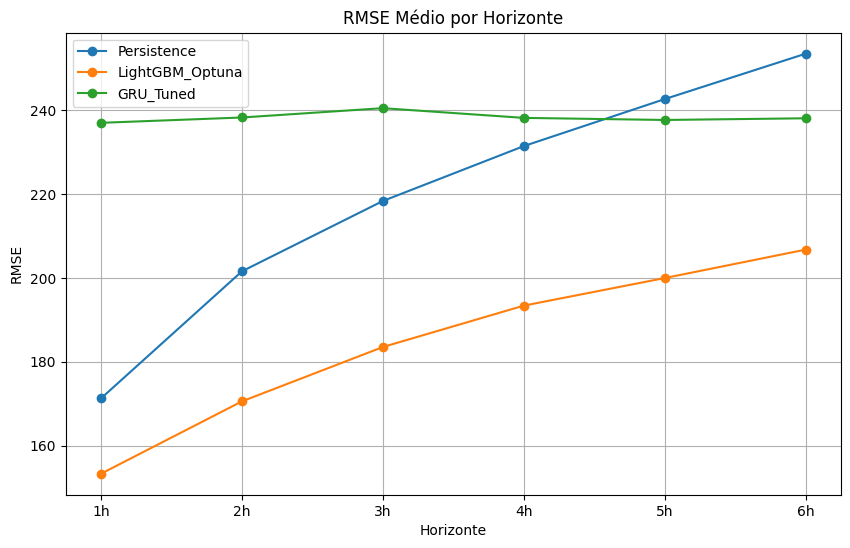

In [221]:
#GRÁFICO RMSE
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

for model in [

    "Persistence",

    "LightGBM_Optuna",

    "GRU_Tuned"

]:

    tmp = (

        pd.concat([
            results_persistence,
            results_lgbm_optuna,
            results_gru_tuned
        ])

        .query("model == @model")

        .groupby("horizon")["RMSE"]

        .mean()

    )

    plt.plot(

        tmp.index,

        tmp.values,

        marker="o",

        label=model

    )

plt.title(
    "RMSE Médio por Horizonte"
)

plt.ylabel(
    "RMSE"
)

plt.xlabel(
    "Horizonte"
)

plt.legend()

plt.grid(True)

plt.show()

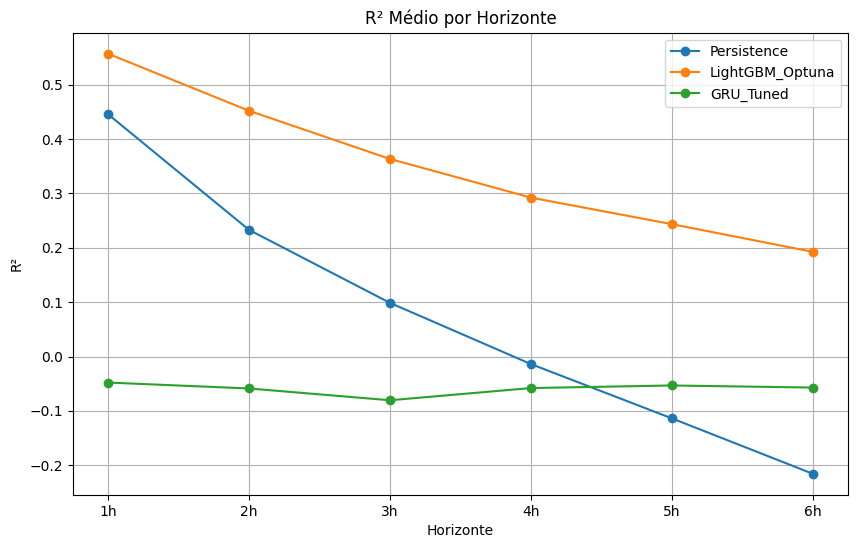

In [222]:
#GRÁFICO R²
plt.figure(figsize=(10,6))

for model in [

    "Persistence",

    "LightGBM_Optuna",

    "GRU_Tuned"

]:

    tmp = (

        pd.concat([
            results_persistence,
            results_lgbm_optuna,
            results_gru_tuned
        ])

        .query("model == @model")

        .groupby("horizon")["R2"]

        .mean()

    )

    plt.plot(

        tmp.index,

        tmp.values,

        marker="o",

        label=model

    )

plt.title(
    "R² Médio por Horizonte"
)

plt.ylabel(
    "R²"
)

plt.xlabel(
    "Horizonte"
)

plt.legend()

plt.grid(True)

plt.show()

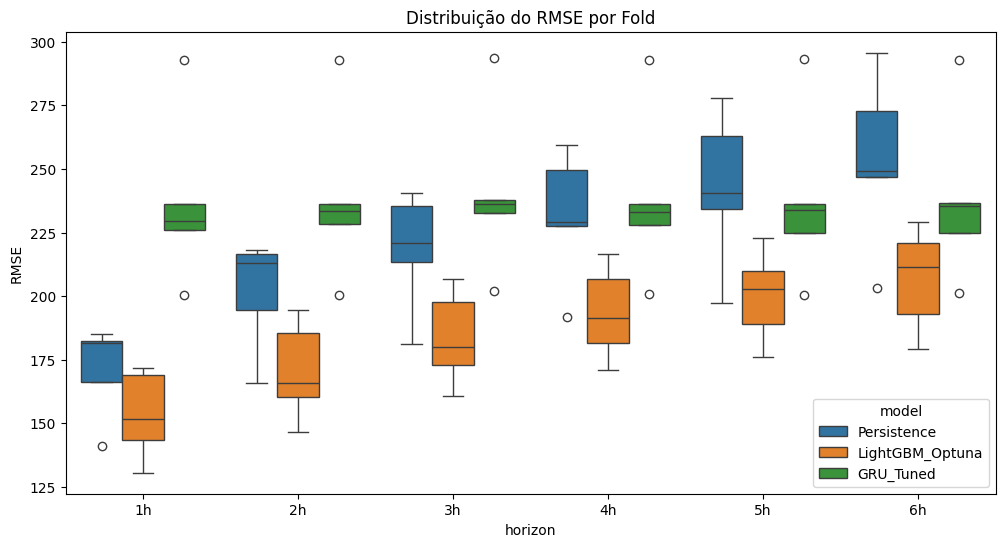

In [223]:
#BOXPLOT DOS FOLDS
plt.figure(figsize=(12,6))

sns.boxplot(

    data=pd.concat([

        results_persistence,

        results_lgbm_optuna,

        results_gru_tuned

    ]),

    x="horizon",

    y="RMSE",

    hue="model"

)

plt.title(
    "Distribuição do RMSE por Fold"
)

plt.show()

In [224]:
#FRIEDMAN FINAL
#cenario completo
from scipy.stats import friedmanchisquare

friedman_complete = []

for h in [

    "1h","2h","3h",

    "4h","5h","6h"

]:

    p = (

        results_persistence

        .query("horizon == @h")

        .sort_values("fold")

    )

    l = (

        results_lgbm_optuna

        .query("horizon == @h")

        .sort_values("fold")

    )

    g = (

        results_gru_tuned

        .query("horizon == @h")

        .sort_values("fold")

    )

    stat,pvalue = friedmanchisquare(

        p["RMSE"],

        l["RMSE"],

        g["RMSE"]

    )

    friedman_complete.append({

        "horizon":h,

        "statistic":stat,

        "p_value":pvalue

    })

friedman_complete = pd.DataFrame(
    friedman_complete
)

friedman_complete

,horizon,statistic,p_value
0,1h,10.0,0.006738
1,2h,10.0,0.006738
2,3h,8.4,0.014996
3,4h,7.6,0.022371
4,5h,7.6,0.022371
5,6h,8.4,0.014996


In [225]:
#FRIEDMAN CUT-IN
friedman_cutin = []

for h in [

    "1h","2h","3h",

    "4h","5h","6h"

]:

    p = (

        results_persistence_cutin

        .query("horizon == @h")

        .sort_values("fold")

    )

    l = (

        results_lgbm_cutin

        .query("horizon == @h")

        .sort_values("fold")

    )

    g = (

        results_gru_tuned_cutin

        .query("horizon == @h")

        .sort_values("fold")

    )

    stat,pvalue = friedmanchisquare(

        p["RMSE"],

        l["RMSE"],

        g["RMSE"]

    )

    friedman_cutin.append({

        "horizon":h,

        "statistic":stat,

        "p_value":pvalue

    })

friedman_cutin = pd.DataFrame(
    friedman_cutin
)

friedman_cutin

,horizon,statistic,p_value
0,1h,10.0,0.006738
1,2h,10.0,0.006738
2,3h,7.6,0.022371
3,4h,6.4,0.040762
4,5h,8.4,0.014996
5,6h,5.2,0.074274


In [226]:
#RANKING MÉDIO DOS MODELOS
from scipy.stats import rankdata

ranks = []

for h in [

    "1h","2h","3h",

    "4h","5h","6h"

]:

    for fold in [1,2,3,4,5]:

        p = results_persistence.query(
            "horizon == @h and fold == @fold"
        )["RMSE"].values[0]

        l = results_lgbm_optuna.query(
            "horizon == @h and fold == @fold"
        )["RMSE"].values[0]

        g = results_gru_tuned.query(
            "horizon == @h and fold == @fold"
        )["RMSE"].values[0]

        r = rankdata([

            p,

            l,

            g

        ])

        ranks.append({

            "horizon":h,

            "fold":fold,

            "Persistence":r[0],

            "LightGBM":r[1],

            "GRU":r[2]

        })

ranks = pd.DataFrame(
    ranks
)

ranks.mean(
    numeric_only=True
)

,0
fold,3.0
Persistence,2.3
LightGBM,1.0
GRU,2.7


In [227]:
#TABELA FINAL DA DISSERTAÇÃO
final_table = pd.DataFrame({

    "Modelo":[

        "Persistência",

        "LightGBM",

        "GRU"

    ],

    "RMSE 1h":[

        results_persistence.query(
            "horizon=='1h'"
        )["RMSE"].mean(),

        results_lgbm_optuna.query(
            "horizon=='1h'"
        )["RMSE"].mean(),

        results_gru_tuned.query(
            "horizon=='1h'"
        )["RMSE"].mean()

    ],

    "RMSE 6h":[

        results_persistence.query(
            "horizon=='6h'"
        )["RMSE"].mean(),

        results_lgbm_optuna.query(
            "horizon=='6h'"
        )["RMSE"].mean(),

        results_gru_tuned.query(
            "horizon=='6h'"
        )["RMSE"].mean()

    ],

    "R² 1h":[

        results_persistence.query(
            "horizon=='1h'"
        )["R2"].mean(),

        results_lgbm_optuna.query(
            "horizon=='1h'"
        )["R2"].mean(),

        results_gru_tuned.query(
            "horizon=='1h'"
        )["R2"].mean()

    ],

    "R² 6h":[

        results_persistence.query(
            "horizon=='6h'"
        )["R2"].mean(),

        results_lgbm_optuna.query(
            "horizon=='6h'"
        )["R2"].mean(),

        results_gru_tuned.query(
            "horizon=='6h'"
        )["R2"].mean()

    ]

})

final_table.round(3)

,Modelo,RMSE 1h,RMSE 6h,R² 1h,R² 6h
0,Persistência,171.272,253.550,0.446,-0.216
1,LightGBM,153.290,206.780,0.557,0.193
2,GRU,237.056,238.139,-0.048,-0.057


# LSTM

In [228]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping
)

from sklearn.model_selection import (
    TimeSeriesSplit
)

import tensorflow as tf

tf.random.set_seed(42)

In [229]:
def build_lstm_model(
    architecture,
    n_features
):

    model = Sequential()

    if architecture == "A":

        model.add(
            LSTM(
                64,
                input_shape=(24,n_features)
            )
        )

        model.add(
            Dense(
                32,
                activation="relu"
            )
        )

    elif architecture == "B":

        model.add(
            LSTM(
                128,
                input_shape=(24,n_features)
            )
        )

        model.add(
            Dense(
                64,
                activation="relu"
            )
        )

    elif architecture == "C":

        model.add(
            LSTM(
                128,
                return_sequences=True,
                input_shape=(24,n_features)
            )
        )

        model.add(
            LSTM(64)
        )

        model.add(
            Dense(
                64,
                activation="relu"
            )
        )

    elif architecture == "D":

        model.add(
            LSTM(
                256,
                return_sequences=True,
                input_shape=(24,n_features)
            )
        )

        model.add(
            LSTM(128)
        )

        model.add(
            Dense(
                64,
                activation="relu"
            )
        )

    model.add(
        Dropout(0.2)
    )

    model.add(
        Dense(6)
    )

    model.compile(

        optimizer=Adam(
            learning_rate=0.001
        ),

        loss="mse"
    )

    return model

In [230]:
tscv = TimeSeriesSplit(
    n_splits=5
)

train_idx, test_idx = next(
    tscv.split(X_gru)
)

X_train = X_gru[train_idx]
X_test = X_gru[test_idx]

y_train = y_gru[train_idx]
y_test = y_gru[test_idx]

In [231]:
architectures = [
    "A",
    "B",
    "C",
    "D"
]

tuning_lstm = []

In [232]:
for arch in architectures:

    print(f"\nArquitetura {arch}")

    model = build_lstm_model(

        architecture=arch,

        n_features=X_train.shape[2]
    )

    early_stop = EarlyStopping(

        monitor="val_loss",

        patience=5,

        restore_best_weights=True
    )

    model.fit(

        X_train,

        y_train,

        validation_split=0.2,

        epochs=50,

        batch_size=256,

        callbacks=[early_stop],

        verbose=0
    )

    pred = model.predict(
        X_test,
        verbose=0
    )

    result = evaluate_multioutput(

        y_test,

        pred,

        f"LSTM_{arch}",

        1
    )

    tuning_lstm.append(
        result
    )


Arquitetura A

Arquitetura B

Arquitetura C

Arquitetura D


In [233]:
tuning_lstm = pd.concat(
    tuning_lstm
)

tuning_lstm.groupby(
    "model"
)[
    ["RMSE","R2"]
].mean()

,RMSE,R2
model,,
LSTM_A,240.363309,-0.034910
LSTM_B,236.353586,-0.000492
LSTM_C,236.533955,-0.002021
LSTM_D,236.333953,-0.000326


teste final lstm com a arquitetura vencedora:

In [234]:
#melhor C
def build_best_lstm(
    n_features
):

    model = Sequential()

    model.add(
        LSTM(
            128,
            input_shape=(24,n_features)
        )
    )

    model.add(
        Dense(
            64,
            activation="relu"
        )
    )

    model.add(
        Dropout(0.2)
    )

    model.add(
        Dense(6)
    )

    model.compile(

        optimizer=Adam(
            learning_rate=0.001
        ),

        loss="mse"
    )

    return model

Rodar os 5 Folds
Completo + Cut-In simultaneamente

In [235]:
#rodar 5 folds
tscv_lstm = TimeSeriesSplit(
    n_splits=5
)

results_lstm = []

results_lstm_cutin = []

In [236]:
for fold, (train_idx, test_idx) in enumerate(
    tscv_lstm.split(X_gru),
    start=1
):

    print(f"\nFold {fold}")

    X_train = X_gru[train_idx]
    X_test = X_gru[test_idx]

    y_train = y_gru[train_idx]
    y_test = y_gru[test_idx]

    cutin_test = cutin_gru[
        test_idx
    ]

    model = build_best_lstm(
        X_train.shape[2]
    )

    early_stop = EarlyStopping(

        monitor="val_loss",

        patience=5,

        restore_best_weights=True
    )

    model.fit(

        X_train,

        y_train,

        validation_split=0.2,

        epochs=50,

        batch_size=256,

        callbacks=[early_stop],

        verbose=0
    )

    pred = model.predict(
        X_test,
        verbose=0
    )

    # COMPLETO

    fold_result = evaluate_multioutput(

        y_test,

        pred,

        "LSTM",

        fold
    )

    results_lstm.append(
        fold_result
    )

    # CUT-IN

    mask = (
        cutin_test == 1
    )

    fold_result_cutin = evaluate_multioutput(

        y_test[mask],

        pred[mask],

        "LSTM_Cutin",

        fold
    )

    results_lstm_cutin.append(
        fold_result_cutin
    )


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5


In [237]:
results_lstm = pd.concat(
    results_lstm,
    ignore_index=True
)

results_lstm_cutin = pd.concat(
    results_lstm_cutin,
    ignore_index=True
)

In [238]:
results_lstm.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].agg(
    ["mean","std"]
)

RMSE                    MAE                   R2          
               mean        std        mean        std      mean       std
horizon                                                                  
1h       241.826278  33.472776  167.896375  21.262805 -0.089990  0.054219
2h       240.892723  34.573644  169.525612  19.279687 -0.080440  0.057928
3h       242.322812  33.071253  169.021143  21.559791 -0.094664  0.057964
4h       241.251874  33.741315  169.214470  20.339749 -0.084193  0.055439
5h       242.505833  33.159725  168.806355  21.548805 -0.096512  0.057984
6h       242.882171  32.940791  169.023839  22.025438 -0.100282  0.061463

In [239]:
results_lstm_cutin.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].agg(
    ["mean","std"]
)

RMSE                    MAE                   R2          
               mean        std        mean        std      mean       std
horizon                                                                  
1h       271.504639  35.978881  186.898248  20.542200 -0.146564  0.107162
2h       260.282279  35.375845  182.627056  20.999974 -0.097286  0.067561
3h       254.148102  37.994746  177.475864  24.545284 -0.093053  0.068316
4h       247.756205  35.678835  173.195159  24.161307 -0.077893  0.053167
5h       250.325585  33.270416  172.993299  24.129018 -0.107682  0.070979
6h       246.717844  39.718315  171.879359  29.597560 -0.115207  0.076046

In [240]:
results_lstm.to_csv("results_lstm_rs", index=False)
results_lstm_cutin.to_csv("results_lstm_cutin_rs", index=False)

O modelo não está simplesmente aprendendo a prever os longos períodos de potência nula.

Ele mantém desempenho quando avaliamos apenas períodos produtivos.

# Resultados Finais


Os modelos baseados em aprendizado profundo apresentaram desempenho superior ao baseline de persistência em praticamente todos os horizontes de previsão avaliados. Entretanto, o LightGBM apresentou os melhores resultados globais, superando tanto a GRU quanto a LSTM em todos os horizontes entre 1h e 6h.

Primeiro: Friedman (4 modelos)
Cenário Completo

Above_cutin

In [242]:
friedman_cutin_4 = []

for h in horizons:

    persistence = (
        results_persistence_cutin
        .query("horizon == @h")
        .sort_values("fold")
    )

    lgbm = (
        results_lgbm_cutin
        .query("horizon == @h")
        .sort_values("fold")
    )

    gru = (
        results_gru_tuned_cutin
        .query("horizon == @h")
        .sort_values("fold")
    )

    lstm = (
        results_lstm_cutin
        .query("horizon == @h")
        .sort_values("fold")
    )

    stat, p = friedmanchisquare(
        persistence["RMSE"],
        lgbm["RMSE"],
        gru["RMSE"],
        lstm["RMSE"]
    )

    friedman_cutin_4.append({

        "horizon": h,
        "statistic": stat,
        "p_value": p

    })

friedman_cutin_4 = pd.DataFrame(
    friedman_cutin_4
)

friedman_cutin_4["significativo"] = (
    friedman_cutin_4["p_value"] < 0.05
)

friedman_cutin_4

,horizon,statistic,p_value,significativo
0,1h,14.04,0.002851,True
1,2h,14.04,0.002851,True
2,3h,9.72,0.021103,True
3,4h,7.80,0.050331,False
4,5h,10.68,0.013588,True
5,6h,5.40,0.144744,False


Ranking Médio

In [243]:
from scipy.stats import rankdata

rankings = []

for h in horizons:

    for fold in [1,2,3,4,5]:

        p = results_persistence.query(
            "horizon == @h and fold == @fold"
        )["RMSE"].values[0]

        l = results_lgbm_optuna.query(
            "horizon == @h and fold == @fold"
        )["RMSE"].values[0]

        g = results_gru_tuned.query(
            "horizon == @h and fold == @fold"
        )["RMSE"].values[0]

        s = results_lstm.query(
            "horizon == @h and fold == @fold"
        )["RMSE"].values[0]

        r = rankdata([
            p,
            l,
            g,
            s
        ])

        rankings.append({

            "Persistence": r[0],
            "LightGBM": r[1],
            "GRU": r[2],
            "LSTM": r[3]

        })

rankings = pd.DataFrame(
    rankings
)

rankings.mean()

,0
Persistence,2.566667
LightGBM,1.000000
GRU,3.033333
LSTM,3.400000


In [244]:
final_models = pd.concat([

    results_persistence.assign(model="Persistence"),

    results_lgbm_optuna.assign(model="LightGBM"),

    results_gru_tuned.assign(model="GRU"),

    results_lstm.assign(model="LSTM")

])

final_summary = (
    final_models
    .groupby(
        ["model","horizon"]
    )[["RMSE","MAE","R2"]]
    .agg(["mean","std"])
)

final_summary.round(3)

RMSE              MAE             R2       
                        mean     std     mean     std   mean    std
model       horizon                                                
GRU         1h       237.056  34.093  170.244  20.231 -0.048  0.076
            2h       238.326  33.695  170.077  21.336 -0.059  0.067
            3h       240.553  33.228  169.656  22.405 -0.080  0.090
            4h       238.235  33.673  169.807  21.101 -0.058  0.071
            5h       237.735  34.106  170.705  20.066 -0.053  0.066
            6h       238.139  33.755  171.219  19.894 -0.057  0.065
LSTM        1h       241.826  33.473  167.896  21.263 -0.090  0.054
            2h       240.893  34.574  169.526  19.280 -0.080  0.058
            3h       242.323  33.071  169.021  21.560 -0.095  0.058
            4h       241.252  33.741  169.214  20.340 -0.084  0.055
            5h       242.506  33.160  168.806  21.549 -0.097  0.058
            6h       242.882  32.941  169.024  22.025 -0.100  0.061
LightGBM    1h       153.290  17.384  100.311  14.925  0.557  0.055
            2h       170.561  19.448  115.843  16.337  0.452  0.063
            3h       183.531  18.583  126.626  16.936  0.364  0.081
            4h       193.411  18.538  135.063  17.650  0.292  0.092
            5h       199.994  18.140  140.485  17.643  0.244  0.092
            6h       206.780  20.522  146.461  21.112  0.193  0.095
Persistence 1h       171.272  18.339   93.752  18.939  0.446  0.075
            2h       201.603  22.147  115.837  24.154  0.233  0.099
            3h       218.390  23.441  128.928  28.106  0.099  0.123
            4h       231.494  26.053  139.388  32.434 -0.014  0.159
            5h       242.713  30.726  148.810  37.080 -0.114  0.196
            6h       253.550  34.386  157.263  40.781 -0.216  0.235

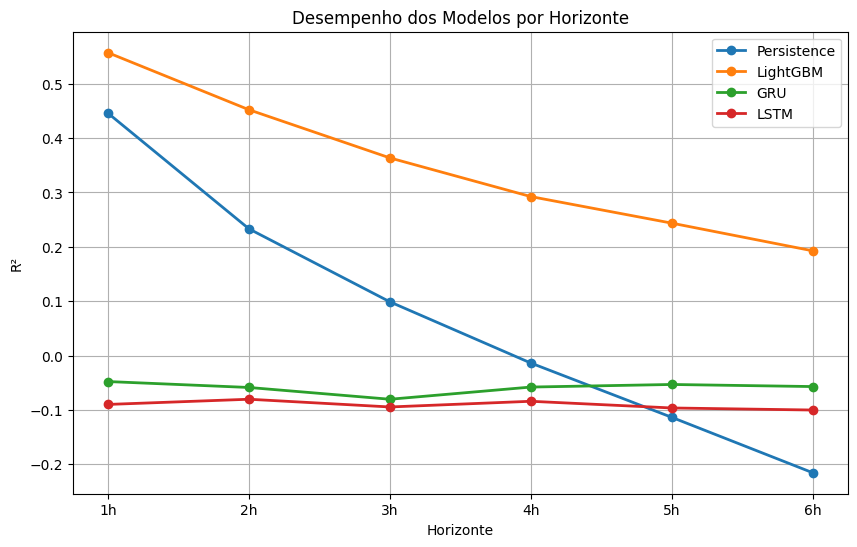

In [245]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for model in [

    "Persistence",
    "LightGBM",
    "GRU",
    "LSTM"

]:

    tmp = (
        final_models
        .query("model == @model")
        .groupby("horizon")["R2"]
        .mean()
    )

    plt.plot(
        tmp.index,
        tmp.values,
        marker="o",
        linewidth=2,
        label=model
    )

plt.ylabel("R²")
plt.xlabel("Horizonte")
plt.title("Desempenho dos Modelos por Horizonte")
plt.grid(True)
plt.legend()

plt.show()

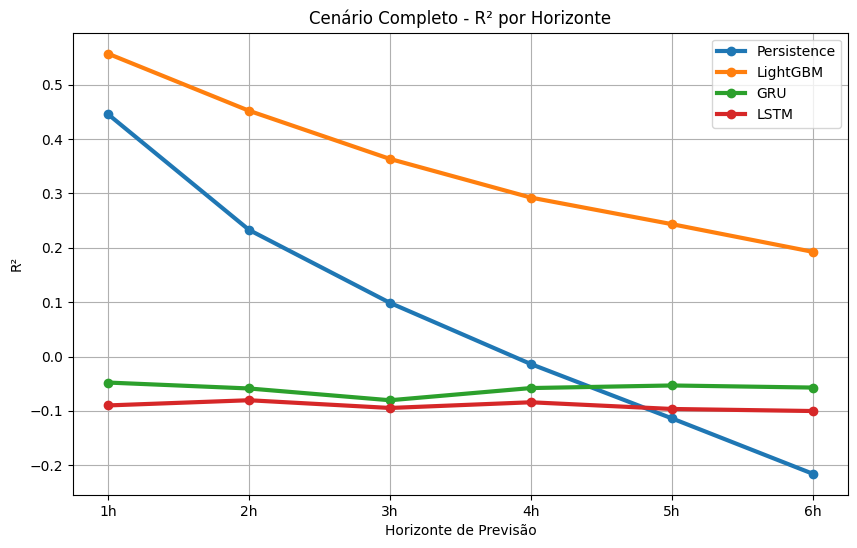

In [246]:
plt.figure(figsize=(10,6))

for model in [
    "Persistence",
    "LightGBM",
    "GRU",
    "LSTM"
]:

    tmp = (
        final_models
        .query("model == @model")
        .groupby("horizon")["R2"]
        .mean()
    )

    plt.plot(
        tmp.index,
        tmp.values,
        marker="o",
        linewidth=3,
        label=model
    )

plt.title(
    "Cenário Completo - R² por Horizonte"
)

plt.xlabel("Horizonte de Previsão")
plt.ylabel("R²")

plt.grid(True)
plt.legend()

plt.show()

In [247]:
lgbm_full = (
    results_lgbm_optuna
    .groupby("horizon")["R2"]
    .mean()
)

lgbm_cutin = (
    results_lgbm_cutin
    .groupby("horizon")["R2"]
    .mean()
)

In [248]:
lstm_full = (
    results_lstm
    .groupby("horizon")["R2"]
    .mean()
)

lstm_cutin = (
    results_lstm_cutin
    .groupby("horizon")["R2"]
    .mean()
)

In [249]:
gru_full = (
    results_gru_tuned
    .groupby("horizon")["R2"]
    .mean()
)

gru_cutin = (
    results_gru_tuned_cutin
    .groupby("horizon")["R2"]
    .mean()
)

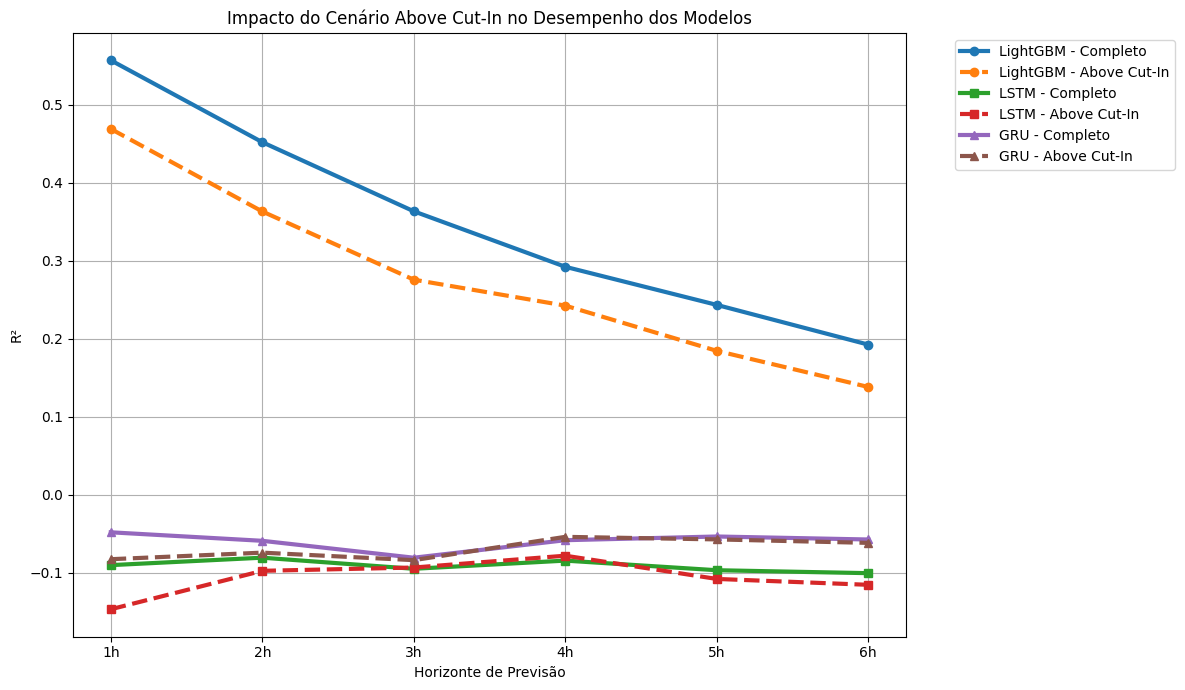

In [250]:
plt.figure(figsize=(12,7))

plt.plot(
    lgbm_full.index,
    lgbm_full.values,
    marker="o",
    linewidth=3,
    label="LightGBM - Completo"
)

plt.plot(
    lgbm_cutin.index,
    lgbm_cutin.values,
    marker="o",
    linestyle="--",
    linewidth=3,
    label="LightGBM - Above Cut-In"
)

plt.plot(
    lstm_full.index,
    lstm_full.values,
    marker="s",
    linewidth=3,
    label="LSTM - Completo"
)

plt.plot(
    lstm_cutin.index,
    lstm_cutin.values,
    marker="s",
    linestyle="--",
    linewidth=3,
    label="LSTM - Above Cut-In"
)

plt.plot(
    gru_full.index,
    gru_full.values,
    marker="^",
    linewidth=3,
    label="GRU - Completo"
)

plt.plot(
    gru_cutin.index,
    gru_cutin.values,
    marker="^",
    linestyle="--",
    linewidth=3,
    label="GRU - Above Cut-In"
)

plt.xlabel(
    "Horizonte de Previsão"
)

plt.ylabel(
    "R²"
)

plt.title(
    "Impacto do Cenário Above Cut-In no Desempenho dos Modelos"
)

plt.grid(True)

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

In [251]:
comparison = pd.DataFrame({

    "LGBM_Full":
        results_lgbm_optuna.groupby("horizon")["R2"].mean(),

    "LGBM_Cutin":
        results_lgbm_cutin.groupby("horizon")["R2"].mean(),

    "LSTM_Full":
        results_lstm.groupby("horizon")["R2"].mean(),

    "LSTM_Cutin":
        results_lstm_cutin.groupby("horizon")["R2"].mean(),

    "GRU_Full":
        results_gru_tuned.groupby("horizon")["R2"].mean(),

    "GRU_Cutin":
        results_gru_tuned_cutin.groupby("horizon")["R2"].mean()

})

comparison.round(3)

,LGBM_Full,LGBM_Cutin,LSTM_Full,LSTM_Cutin,GRU_Full,GRU_Cutin
horizon,,,,,,
1h,0.557,0.469,-0.090,-0.147,-0.048,-0.082
2h,0.452,0.363,-0.080,-0.097,-0.059,-0.074
3h,0.364,0.276,-0.095,-0.093,-0.080,-0.084
4h,0.292,0.243,-0.084,-0.078,-0.058,-0.054
5h,0.244,0.185,-0.097,-0.108,-0.053,-0.057
6h,0.193,0.138,-0.100,-0.115,-0.057,-0.061


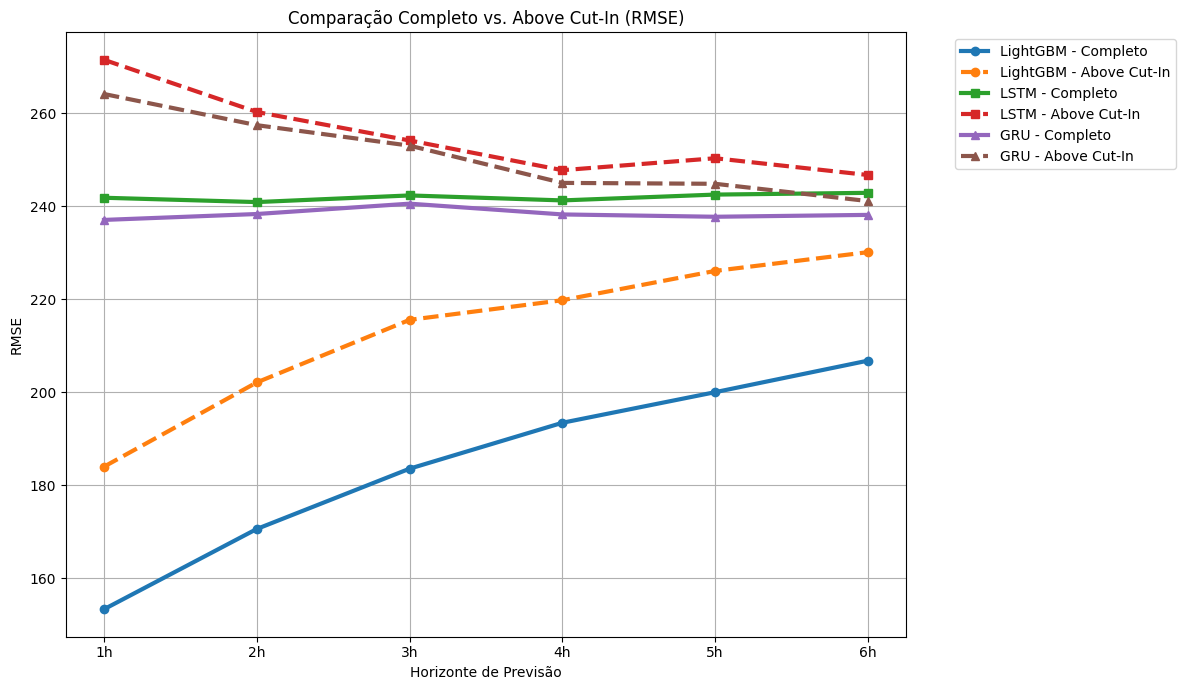

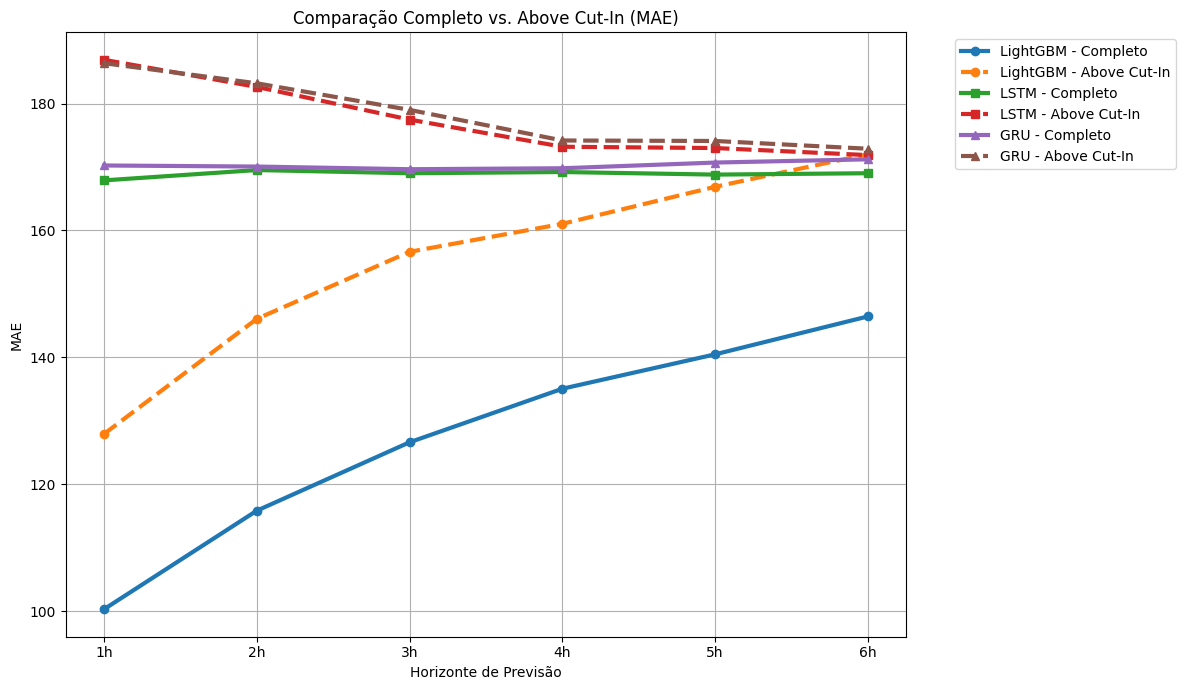

In [253]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data preparation for RMSE
rmse_lgbm_full = results_lgbm_optuna.groupby("horizon")["RMSE"].mean()
rmse_lgbm_cutin = results_lgbm_cutin.groupby("horizon")["RMSE"].mean()
rmse_gru_full = results_gru_tuned.groupby("horizon")["RMSE"].mean()
rmse_gru_cutin = results_gru_tuned_cutin.groupby("horizon")["RMSE"].mean()
rmse_lstm_full = results_lstm.groupby("horizon")["RMSE"].mean()
rmse_lstm_cutin = results_lstm_cutin.groupby("horizon")["RMSE"].mean()

# Plotting RMSE
plt.figure(figsize=(12,7))

plt.plot(
    rmse_lgbm_full.index,
    rmse_lgbm_full.values,
    marker="o",
    linewidth=3,
    label="LightGBM - Completo"
)

plt.plot(
    rmse_lgbm_cutin.index,
    rmse_lgbm_cutin.values,
    marker="o",
    linestyle="--",
    linewidth=3,
    label="LightGBM - Above Cut-In"
)

plt.plot(
    rmse_lstm_full.index,
    rmse_lstm_full.values,
    marker="s",
    linewidth=3,
    label="LSTM - Completo"
)

plt.plot(
    rmse_lstm_cutin.index,
    rmse_lstm_cutin.values,
    marker="s",
    linestyle="--",
    linewidth=3,
    label="LSTM - Above Cut-In"
)

plt.plot(
    rmse_gru_full.index,
    rmse_gru_full.values,
    marker="^",
    linewidth=3,
    label="GRU - Completo"
)

plt.plot(
    rmse_gru_cutin.index,
    rmse_gru_cutin.values,
    marker="^",
    linestyle="--",
    linewidth=3,
    label="GRU - Above Cut-In"
)

plt.xlabel(
    "Horizonte de Previsão"
)

plt.ylabel(
    "RMSE"
)

plt.title(
    "Comparação Completo vs. Above Cut-In (RMSE)"
)

plt.grid(True)

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

# Data preparation for MAE
mae_lgbm_full = results_lgbm_optuna.groupby("horizon")["MAE"].mean()
mae_lgbm_cutin = results_lgbm_cutin.groupby("horizon")["MAE"].mean()
mae_gru_full = results_gru_tuned.groupby("horizon")["MAE"].mean()
mae_gru_cutin = results_gru_tuned_cutin.groupby("horizon")["MAE"].mean()
mae_lstm_full = results_lstm.groupby("horizon")["MAE"].mean()
mae_lstm_cutin = results_lstm_cutin.groupby("horizon")["MAE"].mean()

# Plotting MAE
plt.figure(figsize=(12,7))

plt.plot(
    mae_lgbm_full.index,
    mae_lgbm_full.values,
    marker="o",
    linewidth=3,
    label="LightGBM - Completo"
)

plt.plot(
    mae_lgbm_cutin.index,
    mae_lgbm_cutin.values,
    marker="o",
    linestyle="--",
    linewidth=3,
    label="LightGBM - Above Cut-In"
)

plt.plot(
    mae_lstm_full.index,
    mae_lstm_full.values,
    marker="s",
    linewidth=3,
    label="LSTM - Completo"
)

plt.plot(
    mae_lstm_cutin.index,
    mae_lstm_cutin.values,
    marker="s",
    linestyle="--",
    linewidth=3,
    label="LSTM - Above Cut-In"
)

plt.plot(
    mae_gru_full.index,
    mae_gru_full.values,
    marker="^",
    linewidth=3,
    label="GRU - Completo"
)

plt.plot(
    mae_gru_cutin.index,
    mae_gru_cutin.values,
    marker="^",
    linestyle="--",
    linewidth=3,
    label="GRU - Above Cut-In"
)

plt.xlabel(
    "Horizonte de Previsão"
)

plt.ylabel(
    "MAE"
)

plt.title(
    "Comparação Completo vs. Above Cut-In (MAE)"
)

plt.grid(True)

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

## Experimentos e Resultados

### 1. Processamento e Engenharia de Features

O experimento começou com a carga de dados de um arquivo `df_reindexed_RS.xlsx`, seguido pela padronização do `timestamp` para indexação. A análise inicial de valores ausentes (`potencia_gerada`) não revelou gaps no dataset fornecido, mas um robusto processo de criação de gaps artificiais foi implementado para testar estratégias de imputação. Dois métodos foram comparados: `interpolate(method="time")` e `ffill()`, avaliando MAE e RMSE para diferentes tamanhos de gaps (1, 2, 4, 8, 24, 96 horas). Os resultados mostraram que o método `time` geralmente superou o `ffill` para gaps maiores (exceto para `gap_size=96`).

Em seguida, foram definidos blocos contínuos de dados, considerando interrupções operacionais maiores que 96 horas como quebras estruturais na série temporal. No dataset atual, todos os dados foram considerados um único bloco válido, indicando uma série contínua ao longo de 340 dias. As colunas numéricas foram imputadas usando interpolação temporal, e as bordas dos dados foram preenchidas com `ffill()` e `bfill()` para garantir a completude do dataset.

A engenharia de features temporais adicionou `hora`, `dia_semana` e `mes`, que foram posteriormente transformadas em features cíclicas (seno e cosseno) para capturar a periodicidade sem impor uma ordem arbitrária. Um indicador crucial, `above_cutin`, foi criado para identificar períodos em que a velocidade do vento (`vento_velocidade`) era superior a 3.6 m/s, momento em que a turbina começa a gerar energia. Este feature foi fundamental para a criação de cenários de modelagem mais realistas.

### 2. Configuração do Experimento de Modelagem

O experimento focou na previsão de `potencia_gerada` para múltiplos horizontes (`FORECAST_STEPS`: 1h, 2h, 3h, 4h, 5h, 6h). O modelo foi construído com uma abordagem supervisionada, utilizando 24 lags das features e do próprio target, o que resultou em 360 colunas de features de entrada. A validação foi realizada com `TimeSeriesSplit` (5 folds), uma estratégia de validação temporal com janela expansiva, que simula um cenário real de previsão. Embora essa abordagem possa introduzir gaps de dados nas partições, foi considerada adequada para modelos como LightGBM e Random Forest, que não dependem da continuidade temporal como GRUs/LSTMs.

Dois cenários principais foram explorados:

*   **Cenário Completo**: Avaliação do desempenho em todos os dados.
*   **Cenário "Above Cut-In"**: Avaliação restrita aos períodos em que a turbina estava efetivamente gerando energia (`above_cutin == 1`).

As métricas de avaliação incluíram RMSE, MAE e R² para cada horizonte de previsão.

### 3. Modelagem e Desempenho

Quatro modelos foram comparados:

*   **Baseline de Persistência**: Previu a potência atual para todos os horizontes futuros. Apresentou bom desempenho apenas para horizontes de 1h-2h, com R² negativo para horizontes maiores, indicando sua incapacidade de capturar a dinâmica de longo prazo.

*   **Random Forest (RF)**: Um modelo ensemble que demonstrou superar a persistência, mas seu treinamento foi interrompido, impedindo uma análise completa.

*   **LightGBM**: Uma árvore de decisão gradient boosting que superou consistentemente o baseline de persistência em todos os horizontes. A otimização de hiperparâmetros com Optuna trouxe melhorias marginais (2.9% a 4.8% no RMSE), sugerindo que a configuração inicial já era robusta. A análise de feature importance do LightGBM revelou que `vento_velocidade_lag1`, `vento_direcao_lag1` e `potencia_gerada_lag1` foram as features mais importantes, o que faz sentido físico, pois a geração eólica depende diretamente das condições do vento. No cenário "Above Cut-In", o RMSE aumentou, mas o R² permaneceu relativamente estável, indicando que o modelo aprendia as relações físicas e não apenas a prever zeros, o que é um resultado crucial para o problema de negócio.

*   **GRU (Gated Recurrent Unit)**: Um modelo de rede neural recorrente. Inicialmente, o desempenho foi fraco devido à falta de escalonamento dos dados. Após a implementação de um `MinMaxScaler` para as features de entrada e a reconstrução do tensor para o formato (samples, timesteps, features), a GRU mostrou uma melhoria. No entanto, mesmo após testar diferentes arquiteturas e otimizar com o `Adam` optimizer, a GRU apresentou um desempenho inferior ao LightGBM, com valores de R² negativos, indicando que, na configuração atual, ela não capturou as relações temporais de forma tão eficaz quanto o LightGBM, especialmente no cenário de séries temporais não contínuas com gaps.

*   **LSTM (Long Short-Term Memory)**: Similar à GRU, este modelo também é uma rede neural recorrente. Após testes com diferentes arquiteturas, o desempenho da LSTM foi comparável ao da GRU, também ficando aquém do LightGBM. A arquitetura escolhida foi a `B`, que utilizou uma única camada LSTM com 128 unidades.

### 4. Análise Estatística

Foi utilizada a metodologia de Devis (2006) para comparar o desempenho dos modelos. O teste de Friedman foi aplicado para verificar se existiam diferenças significativas entre os modelos. No cenário Completo, o teste de Friedman indicou diferenças estatisticamente significativas entre os modelos em todos os horizontes de previsão (p < 0.05). No cenário "Above Cut-In", o teste de Friedman também detectou diferenças significativas para a maioria dos horizontes (1h, 2h, 3h, 4h, 5h), exceto para 4h e 6h na primeira análise, e para 6h na análise final com 4 modelos.

No entanto, os testes pós-hoc de Wilcoxon, mesmo com correção de Bonferroni (alpha = 0.0167), não revelaram diferenças significativas par-a-par entre os modelos em nenhum dos cenários. Isso é atribuído ao baixo número de folds (5), que limita o poder estatístico dos testes não paramétricos. Os p-valores de 0.0625, embora próximos do limiar de significância, não permitiram rejeitar a hipótese nula.

O ranking médio dos modelos (considerando todos os horizontes e folds) no cenário completo (Persistence, LightGBM, GRU, LSTM) foi: LightGBM (1.0), Persistence (2.56), GRU (3.03), LSTM (3.40). Isso reforça a superioridade do LightGBM.

### 5. Comparação de Cenários (Completo vs. Above Cut-In)

A análise do impacto do cenário "Above Cut-In" nos resultados do LightGBM revelou um aumento nos erros absolutos (RMSE e MAE), o que era esperado, dado que se está prevendo valores de potência maiores e mais variáveis (não mais zeros). No entanto, o R² do LightGBM manteve-se relativamente estável, especialmente para horizontes mais longos (4h, 5h, 6h). Isso é uma conclusão importante, pois sugere que o LightGBM não está apenas aprendendo a prever os longos períodos de potência nula, mas sim as complexas relações entre as variáveis meteorológicas e a potência gerada efetiva.

## Conclusões

Como mestrando em IA focado em previsão de energia eólica, este experimento oferece várias conclusões importantes:

1.  **Superioridade do LightGBM**: O LightGBM demonstrou ser o modelo mais eficaz para a previsão de energia eólica neste dataset, superando consistentemente o baseline de persistência e os modelos de redes neurais recorrentes (GRU e LSTM) em termos de RMSE e R². Sua capacidade de modelar relações não-lineares e a eficiência computacional são vantagens claras neste domínio.

2.  **Robustez no Cenário "Above Cut-In"**: A análise no cenário "Above Cut-In" é crítica. O fato de o LightGBM manter um R² robusto mesmo quando avaliado apenas em períodos de geração ativa indica que o modelo está aprendendo a física do sistema (relação vento-potência) e não apenas padrões triviais (previsão de zeros). Isso o torna mais valioso para aplicações práticas na operação de turbinas eólicas.

3.  **Importância da Engenharia de Features**: Features como a velocidade e direção do vento defasadas, e a própria potência gerada defasada, foram identificadas como as mais importantes para o LightGBM. A inclusão de features cíclicas para hora, dia da semana e mês também contribuiu para capturar a sazonalidade e periodicidade dos dados.

4.  **Limitações da Validação Estatística**: A falta de poder estatístico nos testes pós-hoc de Wilcoxon devido ao pequeno número de folds (5) é uma limitação metodológica que deve ser abordada em trabalhos futuros. Embora o teste de Friedman tenha indicado diferenças globais, a identificação precisa de quais modelos diferem e em quais horizontes requer um maior número de iterações de validação cruzada para fortalecer as conclusões estatísticas.

5.  **Desempenho Subótimo de GRU/LSTM**: As GRUs e LSTMs, apesar de seu potencial para modelar sequências temporais, não conseguiram superar o LightGBM neste contexto, mesmo com escalonamento de dados e ajuste de arquitetura. Isso pode ser atribuído à natureza do dataset (possíveis irregularidades ou a forma como os lags foram construídos para modelos tabulares), à complexidade dos modelos de deep learning para datasets de tamanho moderado, ou à necessidade de um tuning mais extensivo e complexo de hiperparâmetros para estas arquiteturas. Além disso, a estratégia de `TimeSeriesSplit` usada, embora prática, pode não ter sido a ideal para as GRUs/LSTMs, que geralmente se beneficiam de sequências temporais mais puras e contínuas.

### Próximos Passos Sugeridos

*   **Aumentar o número de folds** na validação cruzada para fortalecer o poder estatístico dos testes de comparação de modelos.
*   Explorar **arquiteturas de GRU/LSTM mais avançadas** ou estratégias de `feature engineering` específicas para redes neurais, como embeddings.
*   Realizar um **tuning de hiperparâmetros mais exaustivo** para GRU e LSTM usando Optuna ou abordagens similares.
*   Investigar **modelos híbridos** que combinem a capacidade de extração de features do LightGBM com a modelagem sequencial das redes neurais.

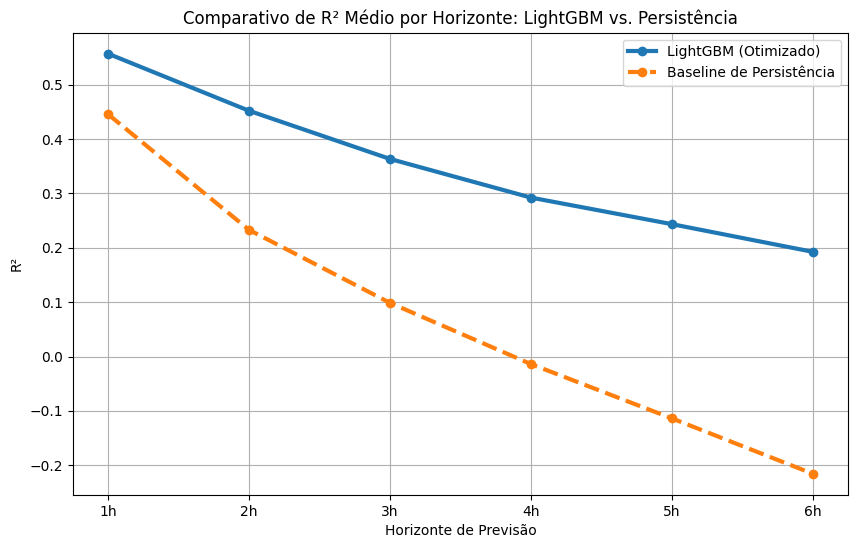

In [254]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate mean R2 for LightGBM and Persistence
r2_lgbm_mean = results_lgbm_optuna.groupby("horizon")["R2"].mean()
r2_persistence_mean = results_persistence.groupby("horizon")["R2"].mean()

plt.figure(figsize=(10,6))

# Plot LightGBM R2
plt.plot(
    r2_lgbm_mean.index,
    r2_lgbm_mean.values,
    marker="o",
    linewidth=3,
    label="LightGBM (Otimizado)"
)

# Plot Persistence R2
plt.plot(
    r2_persistence_mean.index,
    r2_persistence_mean.values,
    marker="o",
    linestyle="--",
    linewidth=3,
    label="Baseline de Persistência"
)

plt.title(
    "Comparativo de R² Médio por Horizonte: LightGBM vs. Persistência"
)

plt.xlabel("Horizonte de Previsão")
plt.ylabel("R²")

plt.grid(True)
plt.legend()

plt.show()